# TINYViT assesment:

Multiple ViT profiles were made in `/config/vit_configs.json`, we trained them in notebook `3.5`, now we evaluate all of those configurations over the unseen validationdata (the 10% part that was taken away in notebook `3.1`). 

The best performing configuration out of this assesment gets trained on the full dataset, without making further changes to the configuration. There is a certain methodological risk involved to go from four to thirty classes. But this effect was hardly seen on using TINYCNN vs the full CNN training (`3.2` vs `3.3`). So I'm fairly optimistic

In [1]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

import sys
sys.path.append('../../utils')
from vit_helpers import ImageDataGeneratorFromDF, PatchEncoder, Patches, get_vit_configurations, evaluate_vit

from configloader import Configloader
import style

import cnn_helpers
import implot


2025-05-03 21:37:18.231631: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
PHASE = 'brand phase'
CROP = True
BATCH_SIZE = 128

In [3]:
cnn_helpers.system_override()
cnn_helpers.system_pick_device()

System override applied - check if GPU is detected
Using GPU for deep learning.


2025-05-03 21:37:20.733792: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-05-03 21:37:23.148904: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-05-03 21:37:23.148977: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero


'GPU'

In [4]:
config = Configloader()

vit_variants = get_vit_configurations(
    os.path.join(
        config.get('directories', 'root_dir'), 
        config.get('settings', 'vit_configurations')
    )
)

In [5]:

basedir = config.get('settings', 'image_directory')
csv_data_dir = config.get('dir_augmentations', 'csv_dir')



In [6]:
csv_dir = os.path.join(basedir, csv_data_dir, PHASE)  #where the train/test/valid split in step 3.1 was done.

In [7]:
validation_df_path = os.path.join(csv_dir, config.get('csv_names', 'brand_validation')) #TODO test this 
validation_df_full = pd.read_csv(validation_df_path)

In [8]:
validation_df_full = cnn_helpers.shuffle_df(validation_df_full)
validation_df_full

,image_id,model_label,model_score,yolobox_top_left_x,yolobox_top_left_y,yolobox_bottom_right_x,yolobox_bottom_right_y,bintag_predicts.image_id,model1_results,model2_results,model3_results,model4_results,brand,abs_path
0,2804870,frontright,0.999953,48,108,675,449,2804870,0.549891,0.999190,0.945690,0.420674,hyundai,/home/frederic/Documents/automotive_image_data...
1,8678402,frontleft,1.000000,173,116,641,401,8678402,0.990425,0.998620,0.889777,0.979160,citroen,/home/frederic/Documents/automotive_image_data...
2,10613297,rearleft,0.999991,107,137,658,409,10613297,0.993272,1.000000,0.993889,0.998315,bmw,/home/frederic/Documents/automotive_image_data...
3,1654537,rearleft,1.000000,96,60,619,407,1654537,0.997361,0.999671,0.956858,0.850139,fiat,/home/frederic/Documents/automotive_image_data...
4,4394910,frontleft,1.000000,116,57,681,470,4394910,0.989116,0.999999,0.985837,0.992103,volkswagen,/home/frederic/Documents/automotive_image_data...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
398790,4039419,rearright,1.000000,87,102,731,448,4039419,0.998527,0.999978,0.897843,0.256661,volkswagen,/home/frederic/Documents/automotive_image_data...
398791,8626539,left,1.000000,40,134,719,412,8626539,0.966379,0.999878,0.968102,0.994188,suzuki,/home/frederic/Documents/automotive_image_data...
398792,10438529,left,1.000000,43,170,692,434,10438529,0.994152,0.999997,0.996214,0.999824,citroen,/home/frederic/Documents/automotive_image_data...
398793,11765227,frontleft,0.965024,110,90,666,382,11765227,0.825717,0.995433,0.837808,0.965057,porsche,/home/frederic/Documents/automotive_image_data...


In [9]:
model_read_dir = os.path.join(config.get('directories', 'root_dir'),
                              config.get('directories', 'vit_dir'))


In [10]:
angles = set()
trained_models = os.listdir(model_read_dir)
for model in trained_models: 
    if model.endswith('.keras'):
        angle = model.split('.')[0].split('=')[-1]
        angles.add(angle)
#The filename-fragment matches the labels stored in SQL; extract and use them like this.

### Let's look at the small models: 

In [11]:
vit_tinydataset_selection = {k:v for k,v in vit_variants.items() if 'max' not in k and '_FULL' not in k}
all_vitTiny_results, all_vitTiny_actuals = evaluate_vit(vit_tinydataset_selection, validation_df_full, model_read_dir, apply_crop=CROP, batchsize= BATCH_SIZE)

Evaluating ViT: ViT1 with PATCH_SIZE=28, PATCHES=64, Tinymode=True
Model ViT1-model_cropped=True_angle=rearleft.keras not found, skipping.
Loading model ViT1-model_cropped=True_angle=front.keras


/home/frederic/Documents/automotive_project/lib/python3.12/site-packages/keras/src/layers/layer.py:396: UserWarning: `build()` was called on layer 'patch_encoder', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
2025-05-03 21:37:24.012337: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-05-03 21:37:24.012472: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-05-03 21:37:24.012537: I external/local_xla/xla/stream_executor/rocm/rocm_executor

Model ViT1-model_cropped=True_angle=frontleft.keras not found, skipping.
Model ViT1-model_cropped=True_angle=rear.keras not found, skipping.
Model ViT1-model_cropped=True_angle=frontright.keras not found, skipping.
Model ViT1-model_cropped=True_angle=left.keras not found, skipping.
Model ViT1-model_cropped=True_angle=rearright.keras not found, skipping.
Model ViT1-model_cropped=True_angle=right.keras not found, skipping.
Evaluating ViT: ViT2 with PATCH_SIZE=28, PATCHES=64, Tinymode=True
Model ViT2-model_cropped=True_angle=rearleft.keras not found, skipping.
Loading model ViT2-model_cropped=True_angle=front.keras


/home/frederic/Documents/automotive_project/lib/python3.12/site-packages/keras/src/layers/layer.py:396: UserWarning: `build()` was called on layer 'patch_encoder', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Model ViT2-model_cropped=True_angle=frontleft.keras not found, skipping.
Model ViT2-model_cropped=True_angle=rear.keras not found, skipping.
Model ViT2-model_cropped=True_angle=frontright.keras not found, skipping.
Model ViT2-model_cropped=True_angle=left.keras not found, skipping.
Model ViT2-model_cropped=True_angle=rearright.keras not found, skipping.
Model ViT2-model_cropped=True_angle=right.keras not found, skipping.
Evaluating ViT: ViT3 with PATCH_SIZE=28, PATCHES=64, Tinymode=True
Model ViT3-model_cropped=True_angle=rearleft.keras not found, skipping.
Loading model ViT3-model_cropped=True_angle=front.keras


...

Model ViT14-model_cropped=True_angle=frontleft.keras not found, skipping.
Model ViT14-model_cropped=True_angle=rear.keras not found, skipping.
Model ViT14-model_cropped=True_angle=frontright.keras not found, skipping.
Model ViT14-model_cropped=True_angle=left.keras not found, skipping.
Model ViT14-model_cropped=True_angle=rearright.keras not found, skipping.
Model ViT14-model_cropped=True_angle=right.keras not found, skipping.
Evaluating ViT: ViT15 with PATCH_SIZE=22, PATCHES=100, Tinymode=True
Model ViT15-model_cropped=True_angle=rearleft.keras not found, skipping.
Loading model ViT15-model_cropped=True_angle=front.keras


/home/frederic/Documents/automotive_project/lib/python3.12/site-packages/keras/src/layers/layer.py:396: UserWarning: `build()` was called on layer 'patch_encoder', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Model ViT15-model_cropped=True_angle=frontleft.keras not found, skipping.
Model ViT15-model_cropped=True_angle=rear.keras not found, skipping.
Model ViT15-model_cropped=True_angle=frontright.keras not found, skipping.
Model ViT15-model_cropped=True_angle=left.keras not found, skipping.
Model ViT15-model_cropped=True_angle=rearright.keras not found, skipping.
Model ViT15-model_cropped=True_angle=right.keras not found, skipping.
Evaluating ViT: ViT16 with PATCH_SIZE=22, PATCHES=100, Tinymode=True
Model ViT16-model_cropped=True_angle=rearleft.keras not found, skipping.
Loading model ViT16-model_cropped=True_angle=front.keras


/home/frederic/Documents/automotive_project/lib/python3.12/site-packages/keras/src/layers/layer.py:396: UserWarning: `build()` was called on layer 'patch_encoder_2', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Model ViT16-model_cropped=True_angle=frontleft.keras not found, skipping.
Model ViT16-model_cropped=True_angle=rear.keras not found, skipping.
Model ViT16-model_cropped=True_angle=frontright.keras not found, skipping.
Model ViT16-model_cropped=True_angle=left.keras not found, skipping.
Model ViT16-model_cropped=True_angle=rearright.keras not found, skipping.
Model ViT16-model_cropped=True_angle=right.keras not found, skipping.


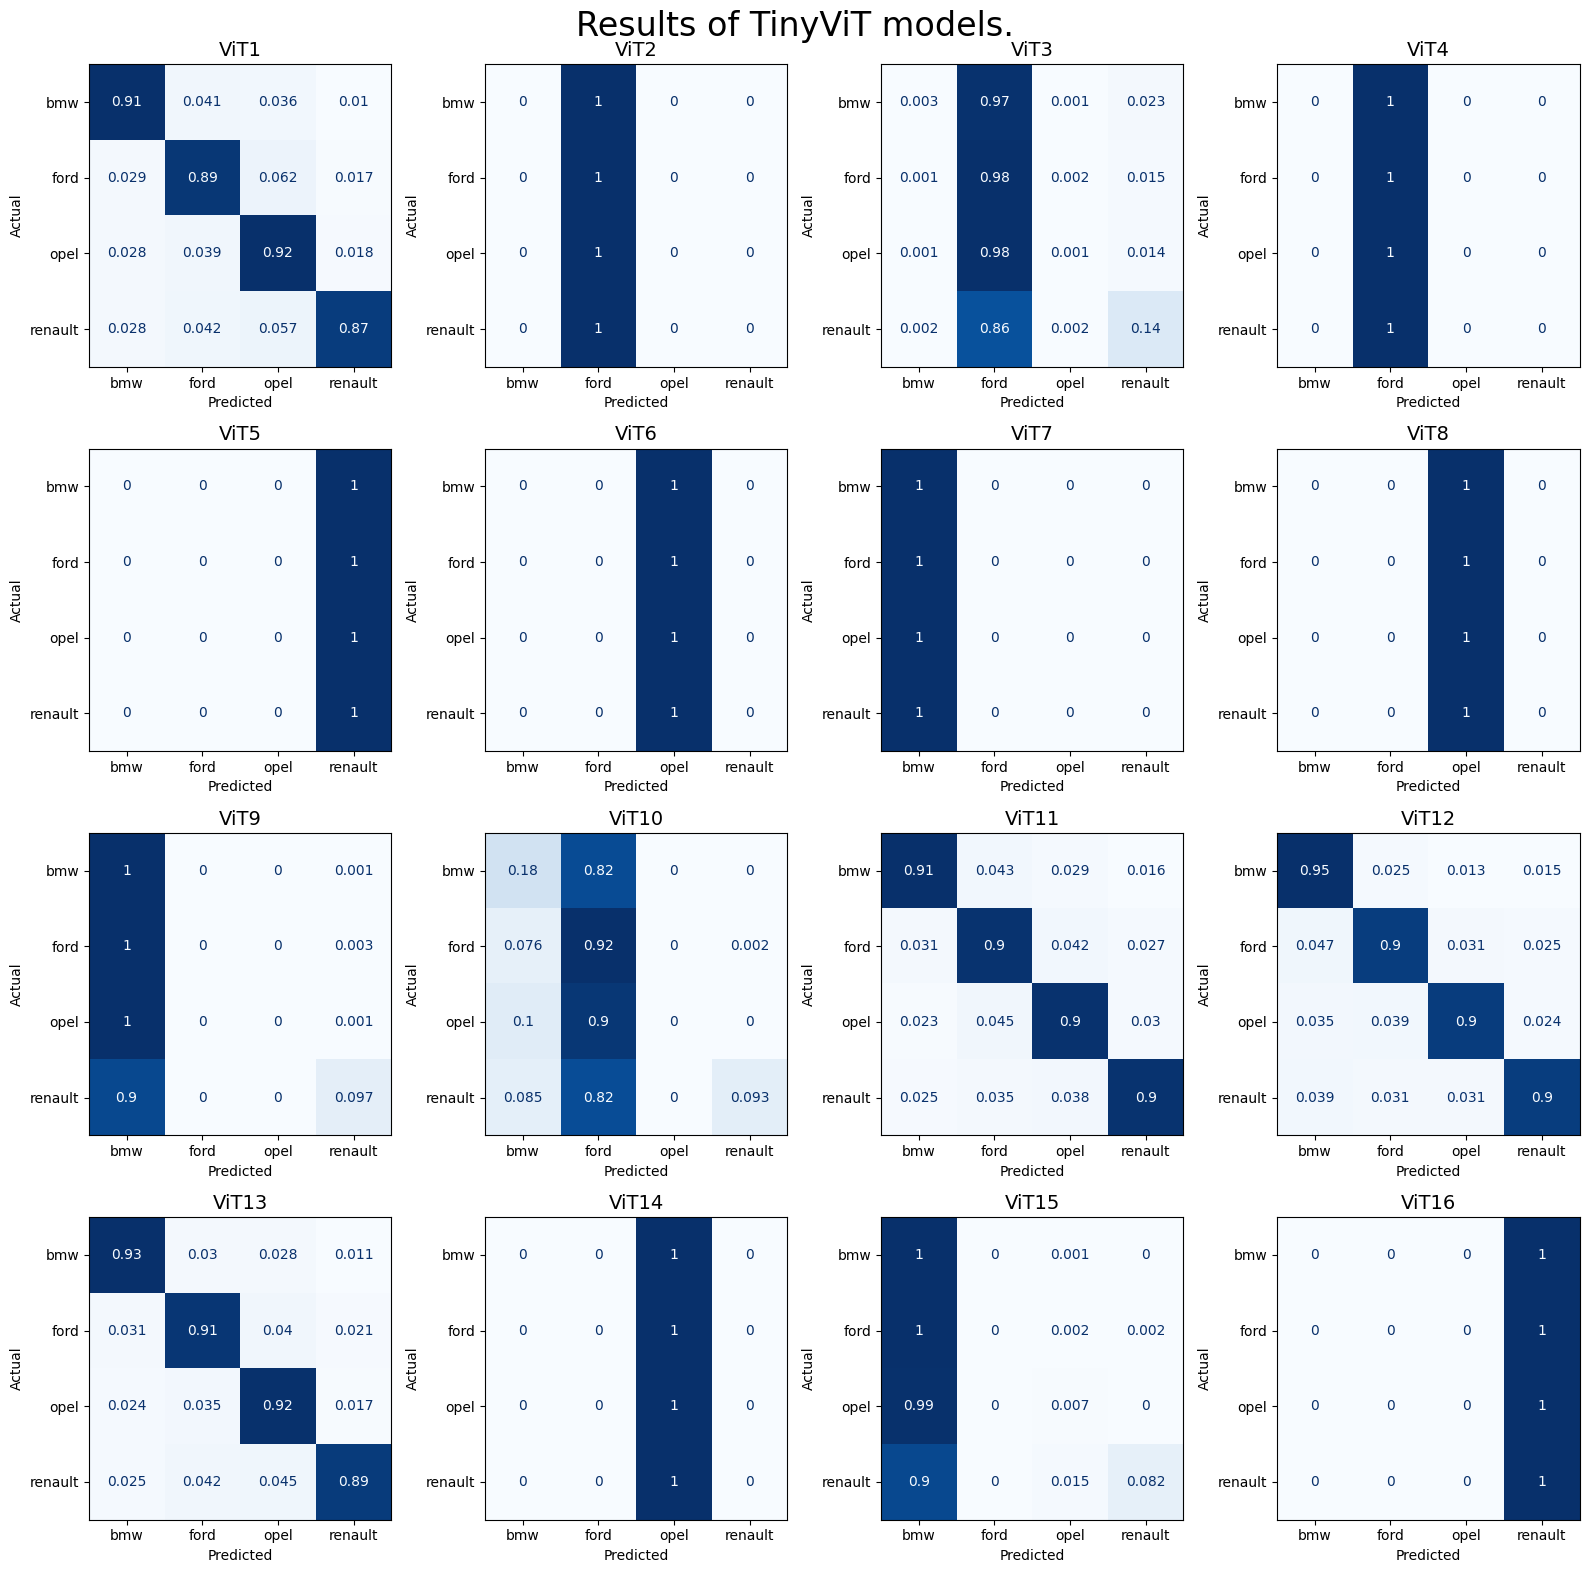

In [12]:
all_vitTiny_results, all_vitTiny_actuals
full_metrics_Tiny = {}
cms = {}
for k in all_vitTiny_results:
    name = k
    pred = np.argmax(all_vitTiny_results[k], axis=1)
    act = all_vitTiny_actuals[k]['data']
    label_encoder = all_vitTiny_actuals[k]['encoder']
    metrics = implot.quick_metrics(act, pred)
    full_metrics_Tiny[k] = metrics
    cm_disp = implot.make_cm(act, pred, label_encoder.classes_, embed=True)
    cms[k] = cm_disp

#Stopped messing around with ViT at 16 Tiny-profiles: 4 by 4 grid suffices abd no cleanup needed either. 
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
axes = axes.flatten()
for i, (k, disp) in enumerate(cms.items()):
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(k, fontsize=14)
    axes[i].set_xlabel("Predicted", fontsize=10)
    axes[i].set_ylabel("Actual", fontsize=10)
plt.suptitle('Results of TinyViT models.', fontsize = 24)
plt.tight_layout()
plt.show()

### Bigger models: 
Based on the small models a few configurations where tested that would train on all classes for a max of 4 epochs. (best score at epoch 4 does not necessarily mean it's the best model at the end), but it is more intended to save some time. 

In [13]:
vit_fulldataset_selection = {k:v for k,v in vit_variants.items() if 'max' in k}
all_vit30_results, all_vit30_actuals = evaluate_vit(vit_fulldataset_selection, validation_df_full, model_read_dir, apply_crop = CROP, batchsize = BATCH_SIZE)



Evaluating ViT: ViT17_max4 with PATCH_SIZE=28, PATCHES=64, Tinymode=False
Model ViT17_max4-model_cropped=True_angle=frontright.keras not found, skipping.
Model ViT17_max4-model_cropped=True_angle=frontleft.keras not found, skipping.
Model ViT17_max4-model_cropped=True_angle=rearleft.keras not found, skipping.
Loading model ViT17_max4-model_cropped=True_angle=front.keras


/home/frederic/Documents/automotive_project/lib/python3.12/site-packages/keras/src/layers/layer.py:396: UserWarning: `build()` was called on layer 'patch_encoder_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Model ViT17_max4-model_cropped=True_angle=left.keras not found, skipping.
Model ViT17_max4-model_cropped=True_angle=rear.keras not found, skipping.
Model ViT17_max4-model_cropped=True_angle=rearright.keras not found, skipping.
Model ViT17_max4-model_cropped=True_angle=right.keras not found, skipping.
Evaluating ViT: ViT18_max4 with PATCH_SIZE=28, PATCHES=64, Tinymode=False
Model ViT18_max4-model_cropped=True_angle=frontright.keras not found, skipping.
Model ViT18_max4-model_cropped=True_angle=frontleft.keras not found, skipping.
Model ViT18_max4-model_cropped=True_angle=rearleft.keras not found, skipping.
Loading model ViT18_max4-model_cropped=True_angle=front.keras


/home/frederic/Documents/automotive_project/lib/python3.12/site-packages/keras/src/layers/layer.py:396: UserWarning: `build()` was called on layer 'patch_encoder_2', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Model ViT18_max4-model_cropped=True_angle=left.keras not found, skipping.
Model ViT18_max4-model_cropped=True_angle=rear.keras not found, skipping.
Model ViT18_max4-model_cropped=True_angle=rearright.keras not found, skipping.
Model ViT18_max4-model_cropped=True_angle=right.keras not found, skipping.
Evaluating ViT: ViT19_max4 with PATCH_SIZE=28, PATCHES=64, Tinymode=False
Model ViT19_max4-model_cropped=True_angle=frontright.keras not found, skipping.
Model ViT19_max4-model_cropped=True_angle=frontleft.keras not found, skipping.
Model ViT19_max4-model_cropped=True_angle=rearleft.keras not found, skipping.
Loading model ViT19_max4-model_cropped=True_angle=front.keras


...

Model ViT25_max4-model_cropped=True_angle=left.keras not found, skipping.
Model ViT25_max4-model_cropped=True_angle=rear.keras not found, skipping.
Model ViT25_max4-model_cropped=True_angle=rearright.keras not found, skipping.
Model ViT25_max4-model_cropped=True_angle=right.keras not found, skipping.
Evaluating ViT: ViT26_max4 with PATCH_SIZE=22, PATCHES=100, Tinymode=False
Model ViT26_max4-model_cropped=True_angle=frontright.keras not found, skipping.
Model ViT26_max4-model_cropped=True_angle=frontleft.keras not found, skipping.
Model ViT26_max4-model_cropped=True_angle=rearleft.keras not found, skipping.
Loading model ViT26_max4-model_cropped=True_angle=front.keras


/home/frederic/Documents/automotive_project/lib/python3.12/site-packages/keras/src/layers/layer.py:396: UserWarning: `build()` was called on layer 'patch_encoder', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Model ViT26_max4-model_cropped=True_angle=left.keras not found, skipping.
Model ViT26_max4-model_cropped=True_angle=rear.keras not found, skipping.
Model ViT26_max4-model_cropped=True_angle=rearright.keras not found, skipping.
Model ViT26_max4-model_cropped=True_angle=right.keras not found, skipping.
Evaluating ViT: ViT27_max4 with PATCH_SIZE=22, PATCHES=100, Tinymode=False
Model ViT27_max4-model_cropped=True_angle=frontright.keras not found, skipping.
Model ViT27_max4-model_cropped=True_angle=frontleft.keras not found, skipping.
Model ViT27_max4-model_cropped=True_angle=rearleft.keras not found, skipping.
Loading model ViT27_max4-model_cropped=True_angle=front.keras


/home/frederic/Documents/automotive_project/lib/python3.12/site-packages/keras/src/layers/layer.py:396: UserWarning: `build()` was called on layer 'patch_encoder_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Model ViT27_max4-model_cropped=True_angle=left.keras not found, skipping.
Model ViT27_max4-model_cropped=True_angle=rear.keras not found, skipping.
Model ViT27_max4-model_cropped=True_angle=rearright.keras not found, skipping.
Model ViT27_max4-model_cropped=True_angle=right.keras not found, skipping.


In [14]:
for k in all_vit30_results:
    print(k)

ViT17_max4
ViT18_max4
ViT19_max4
ViT20_max4
ViT21_max4
ViT22_max4
ViT23_max4
ViT24_max4
ViT25_max4
ViT26_max4
ViT27_max4


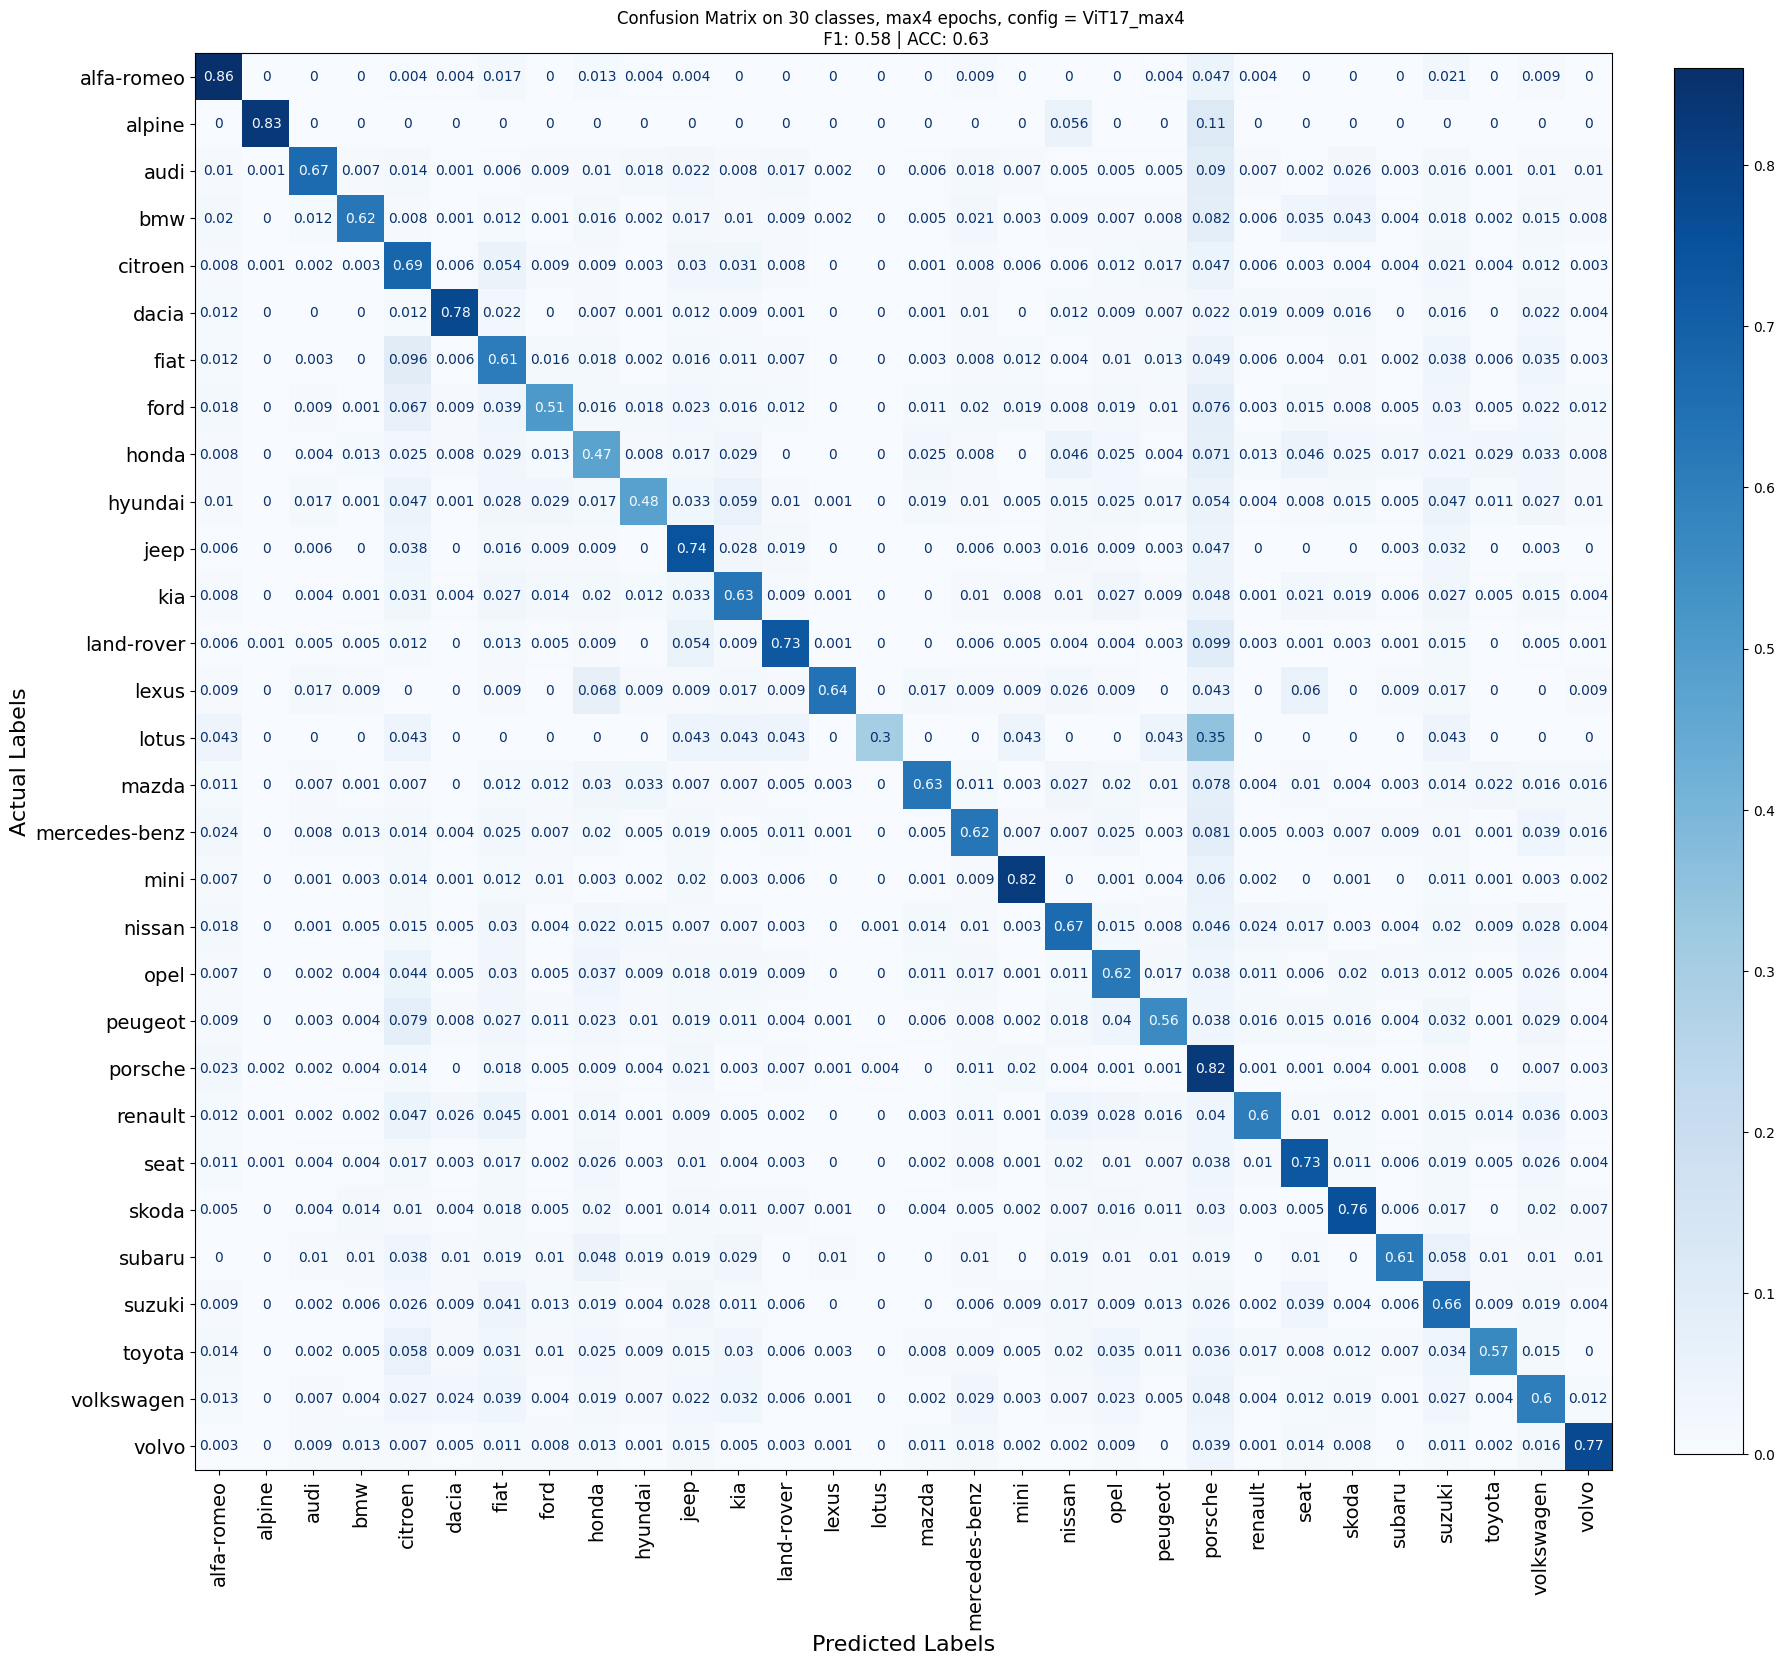

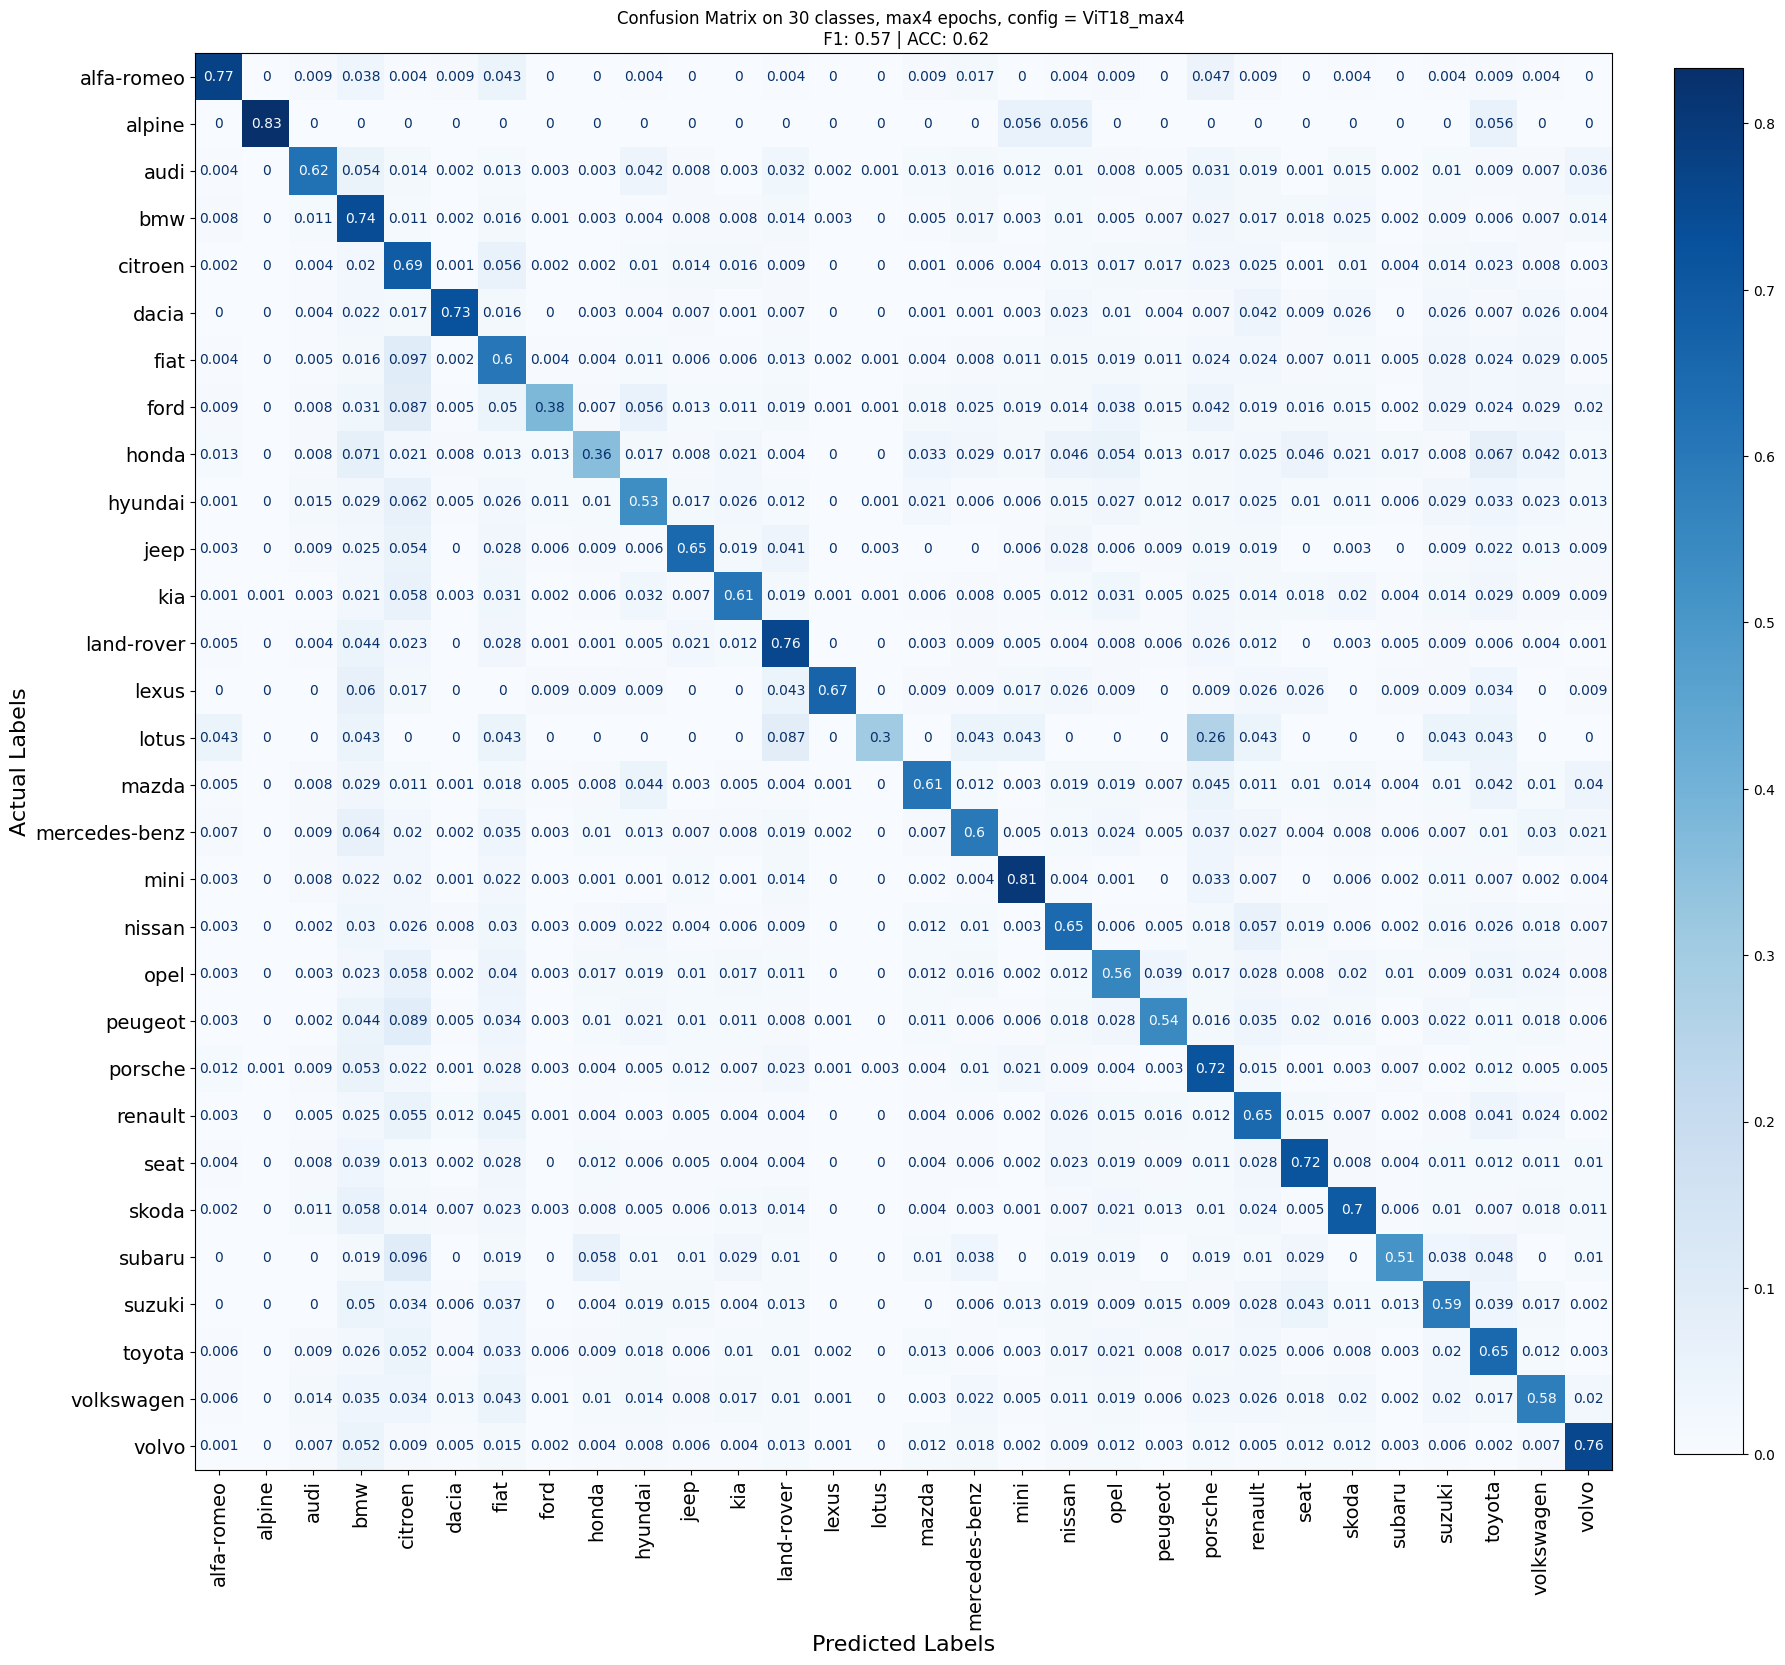

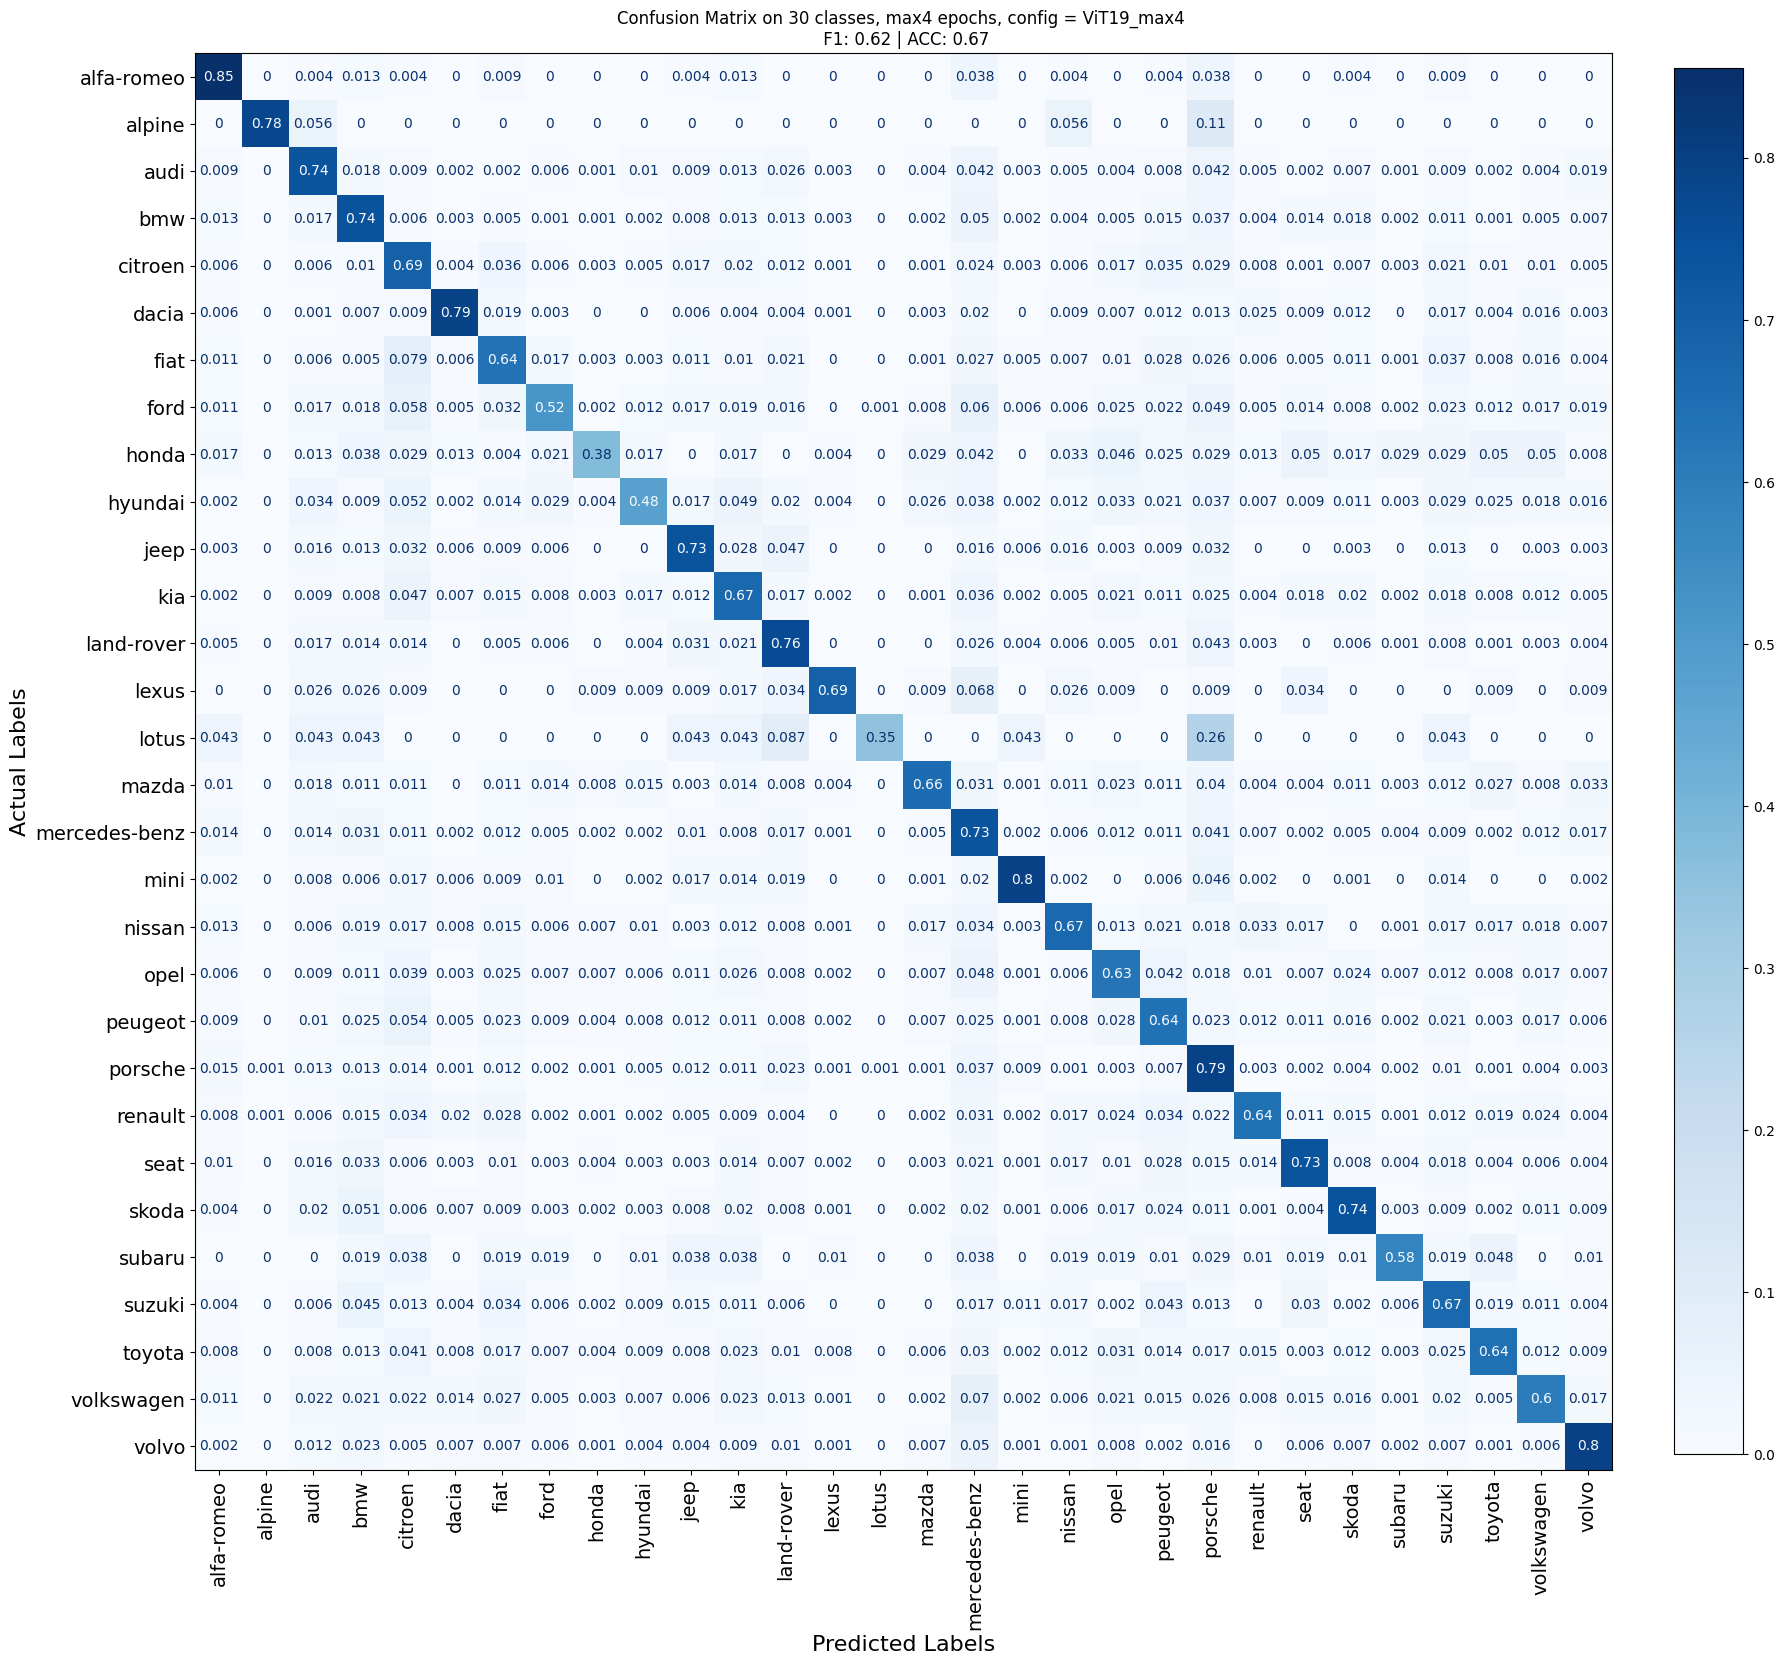

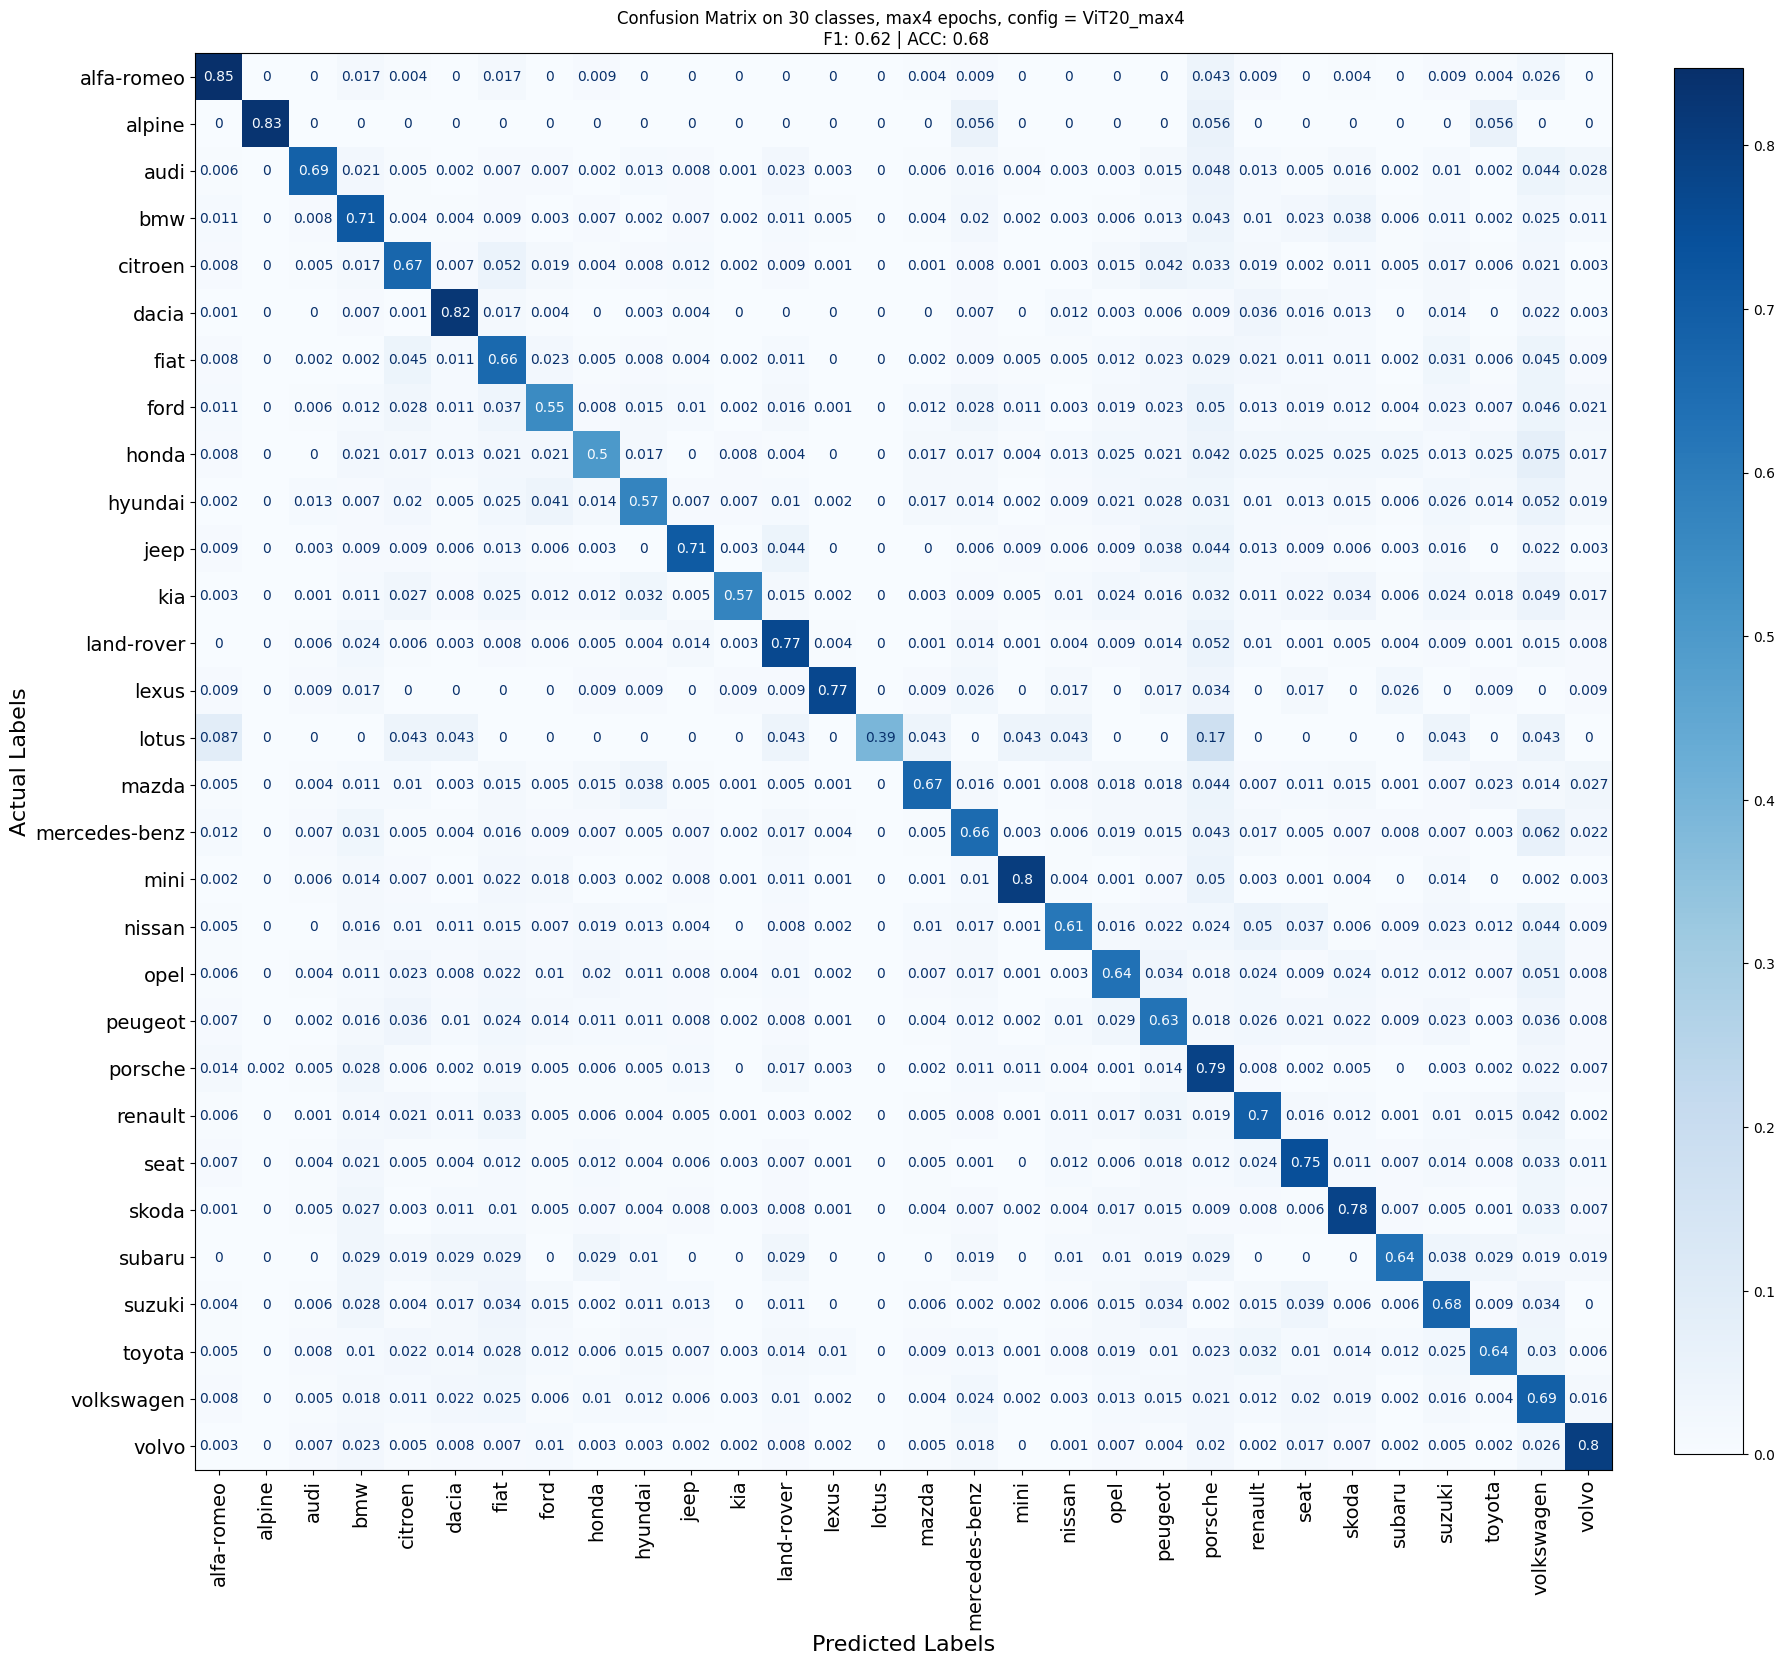

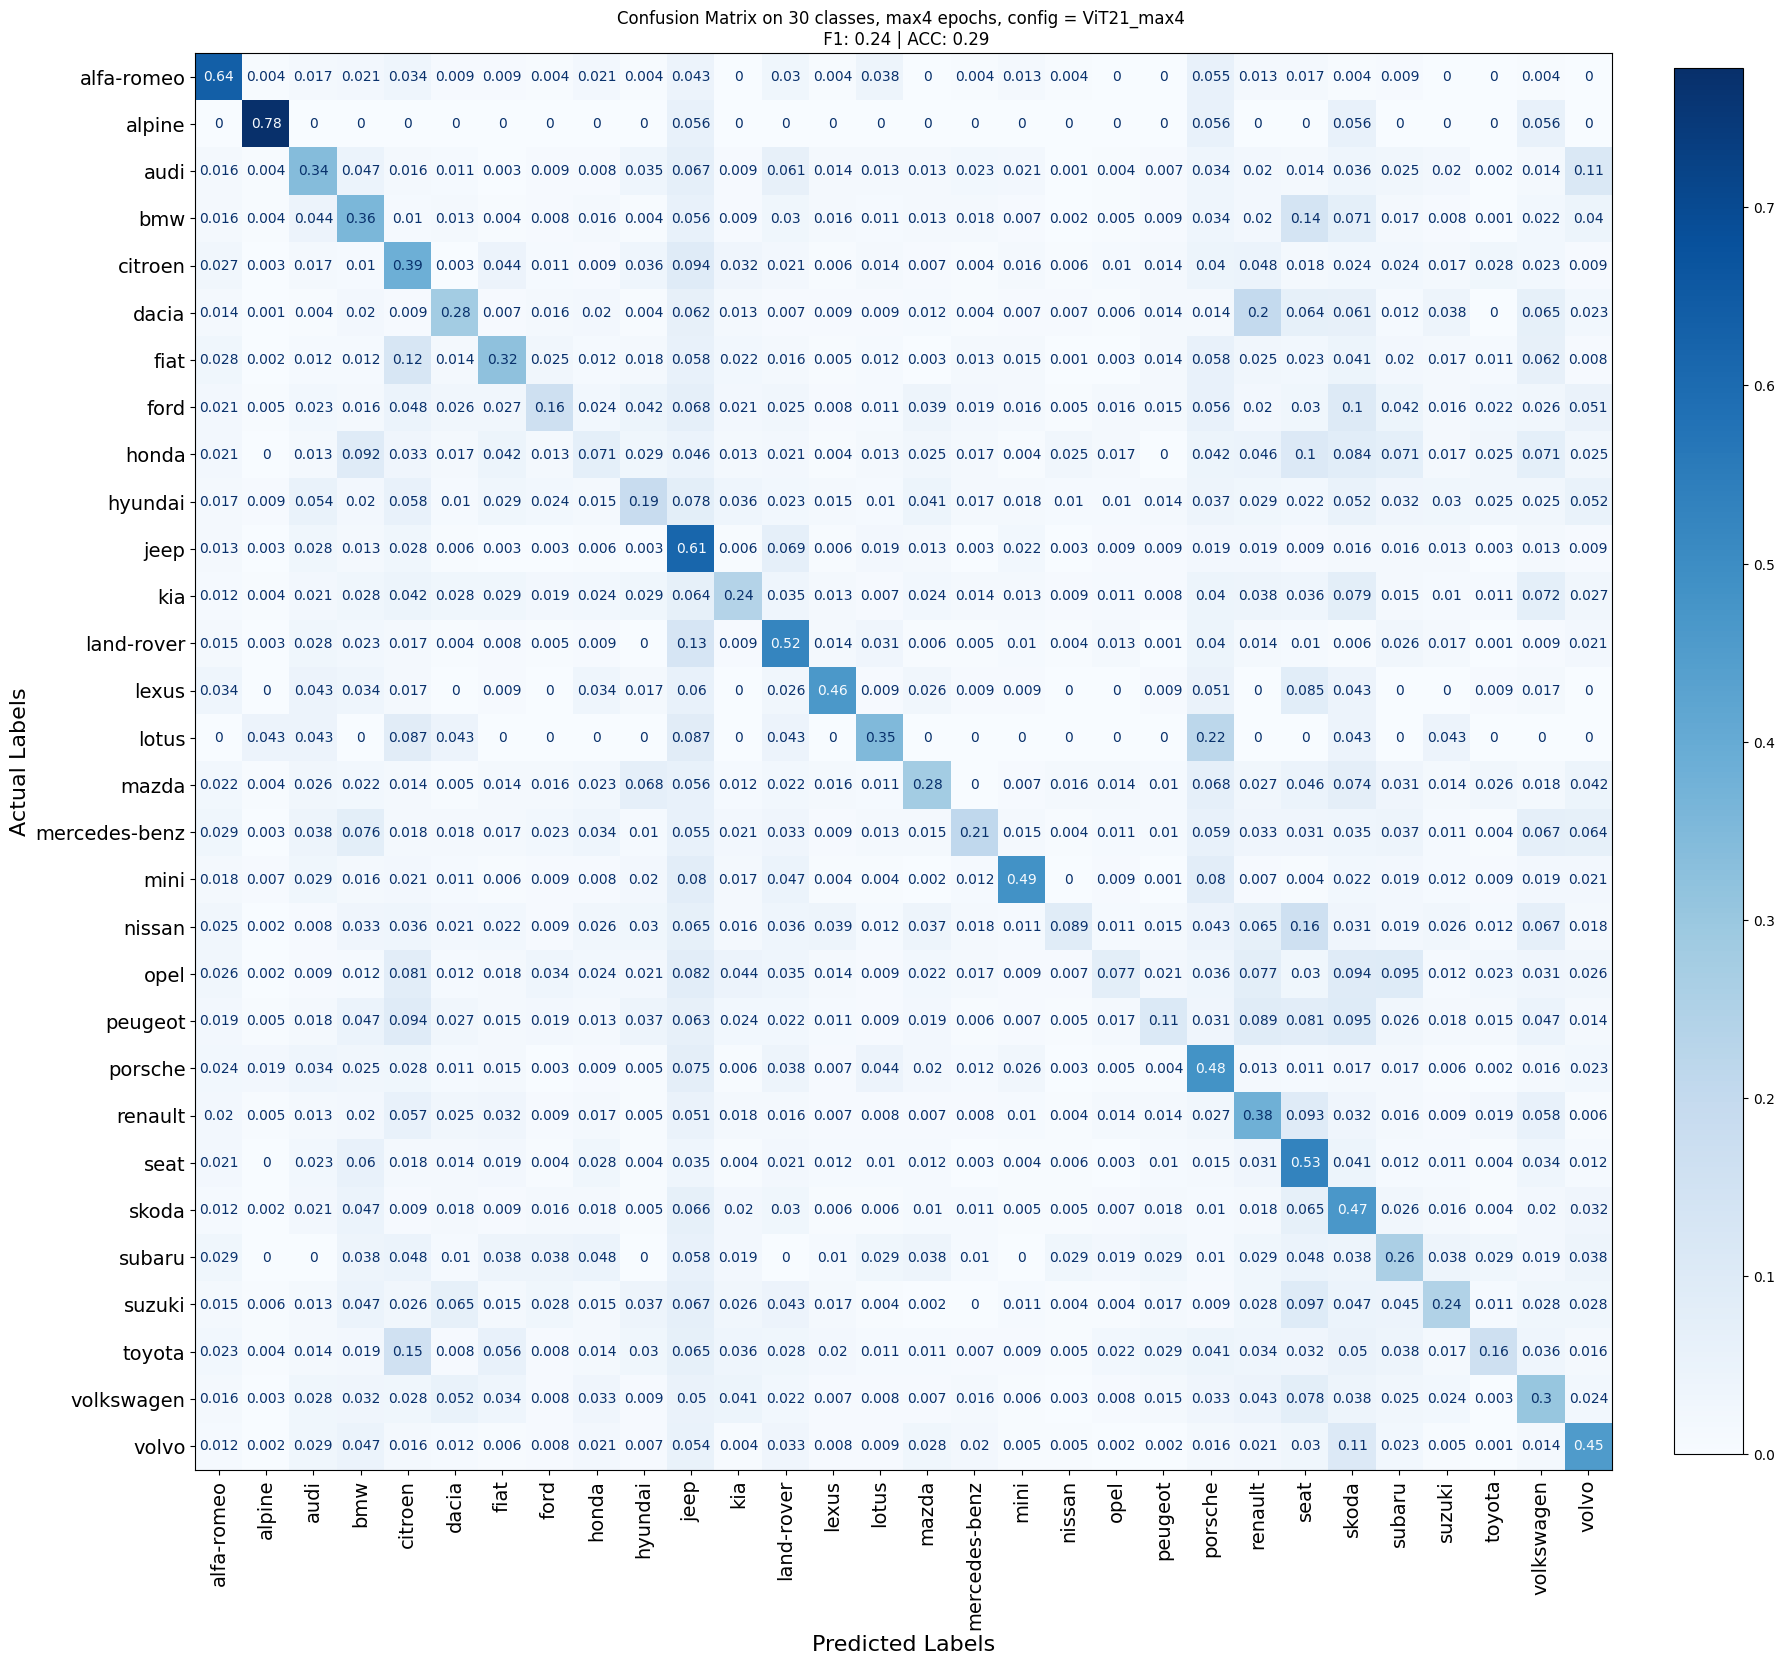

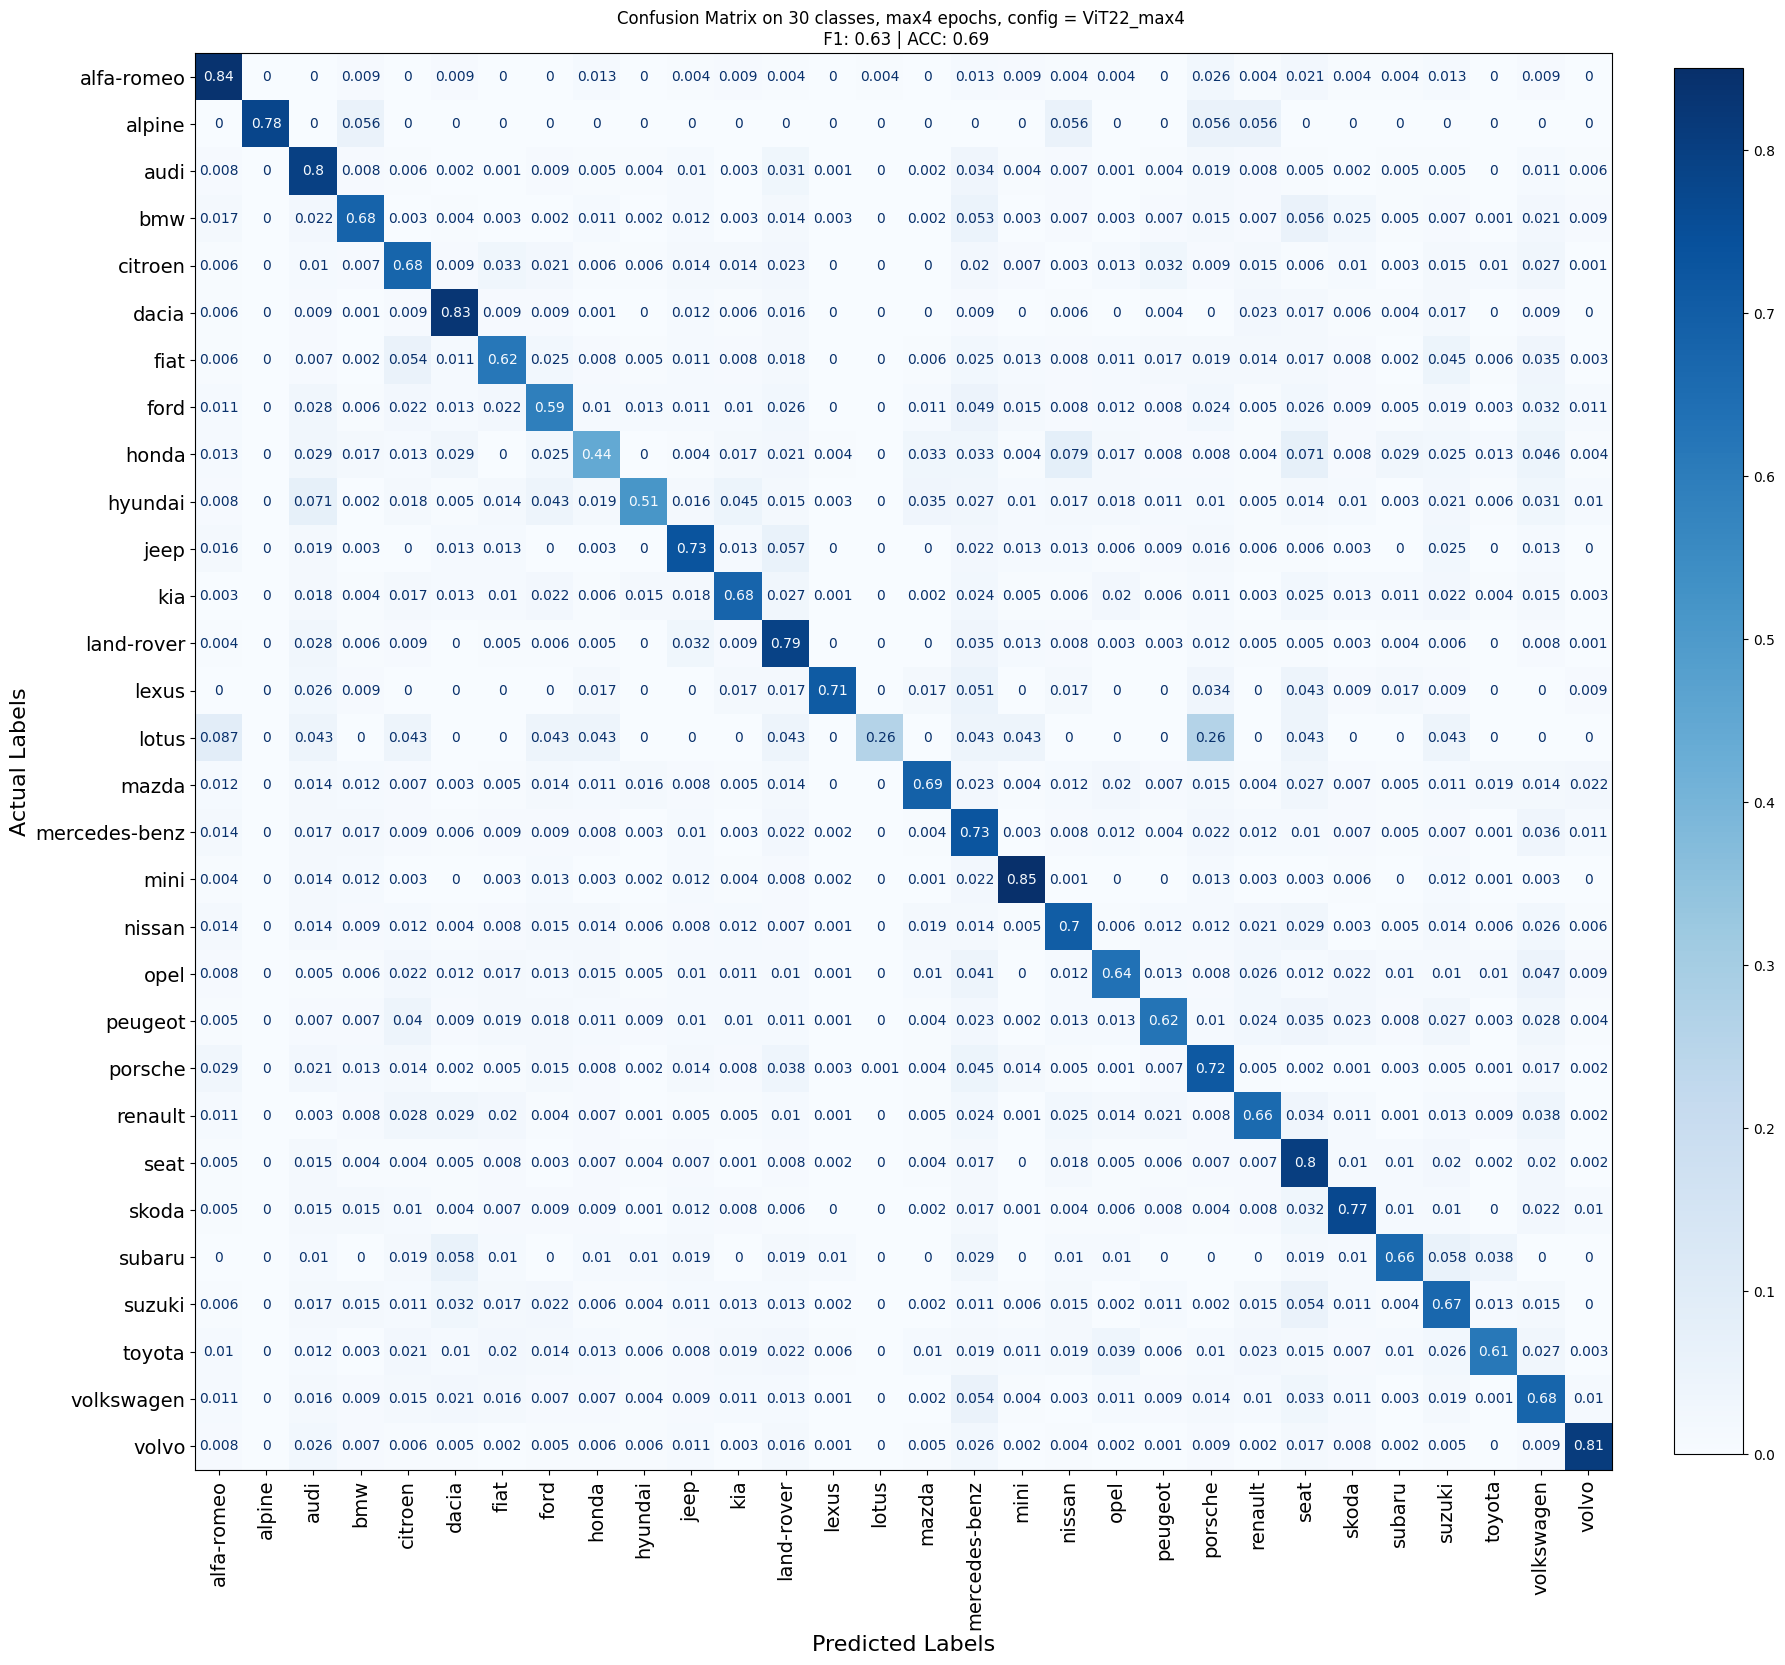

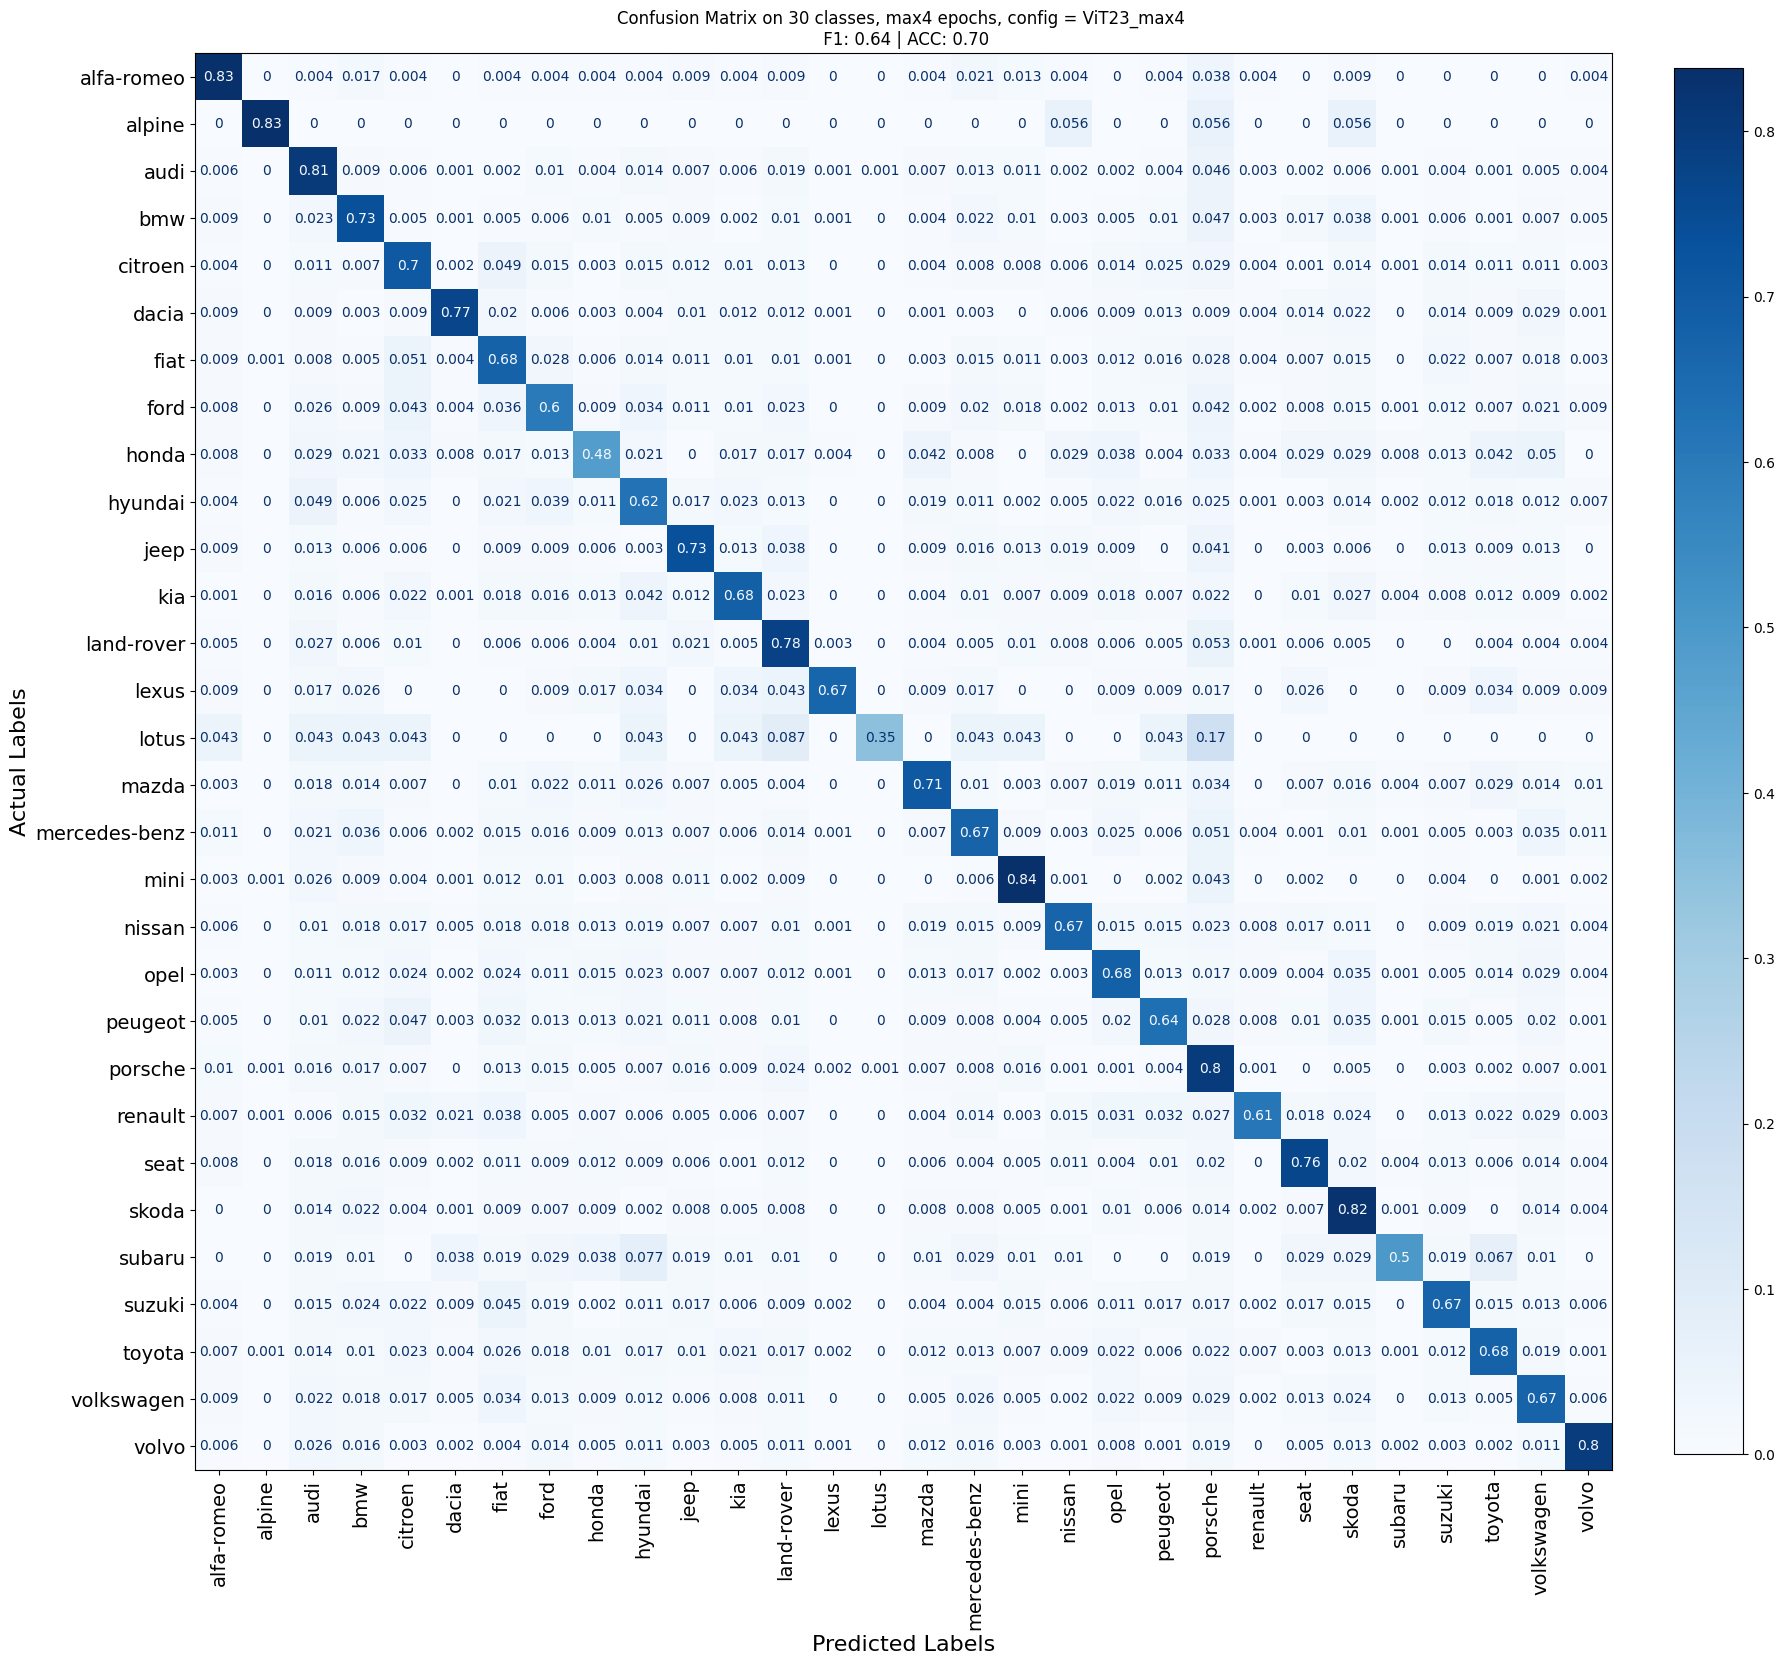

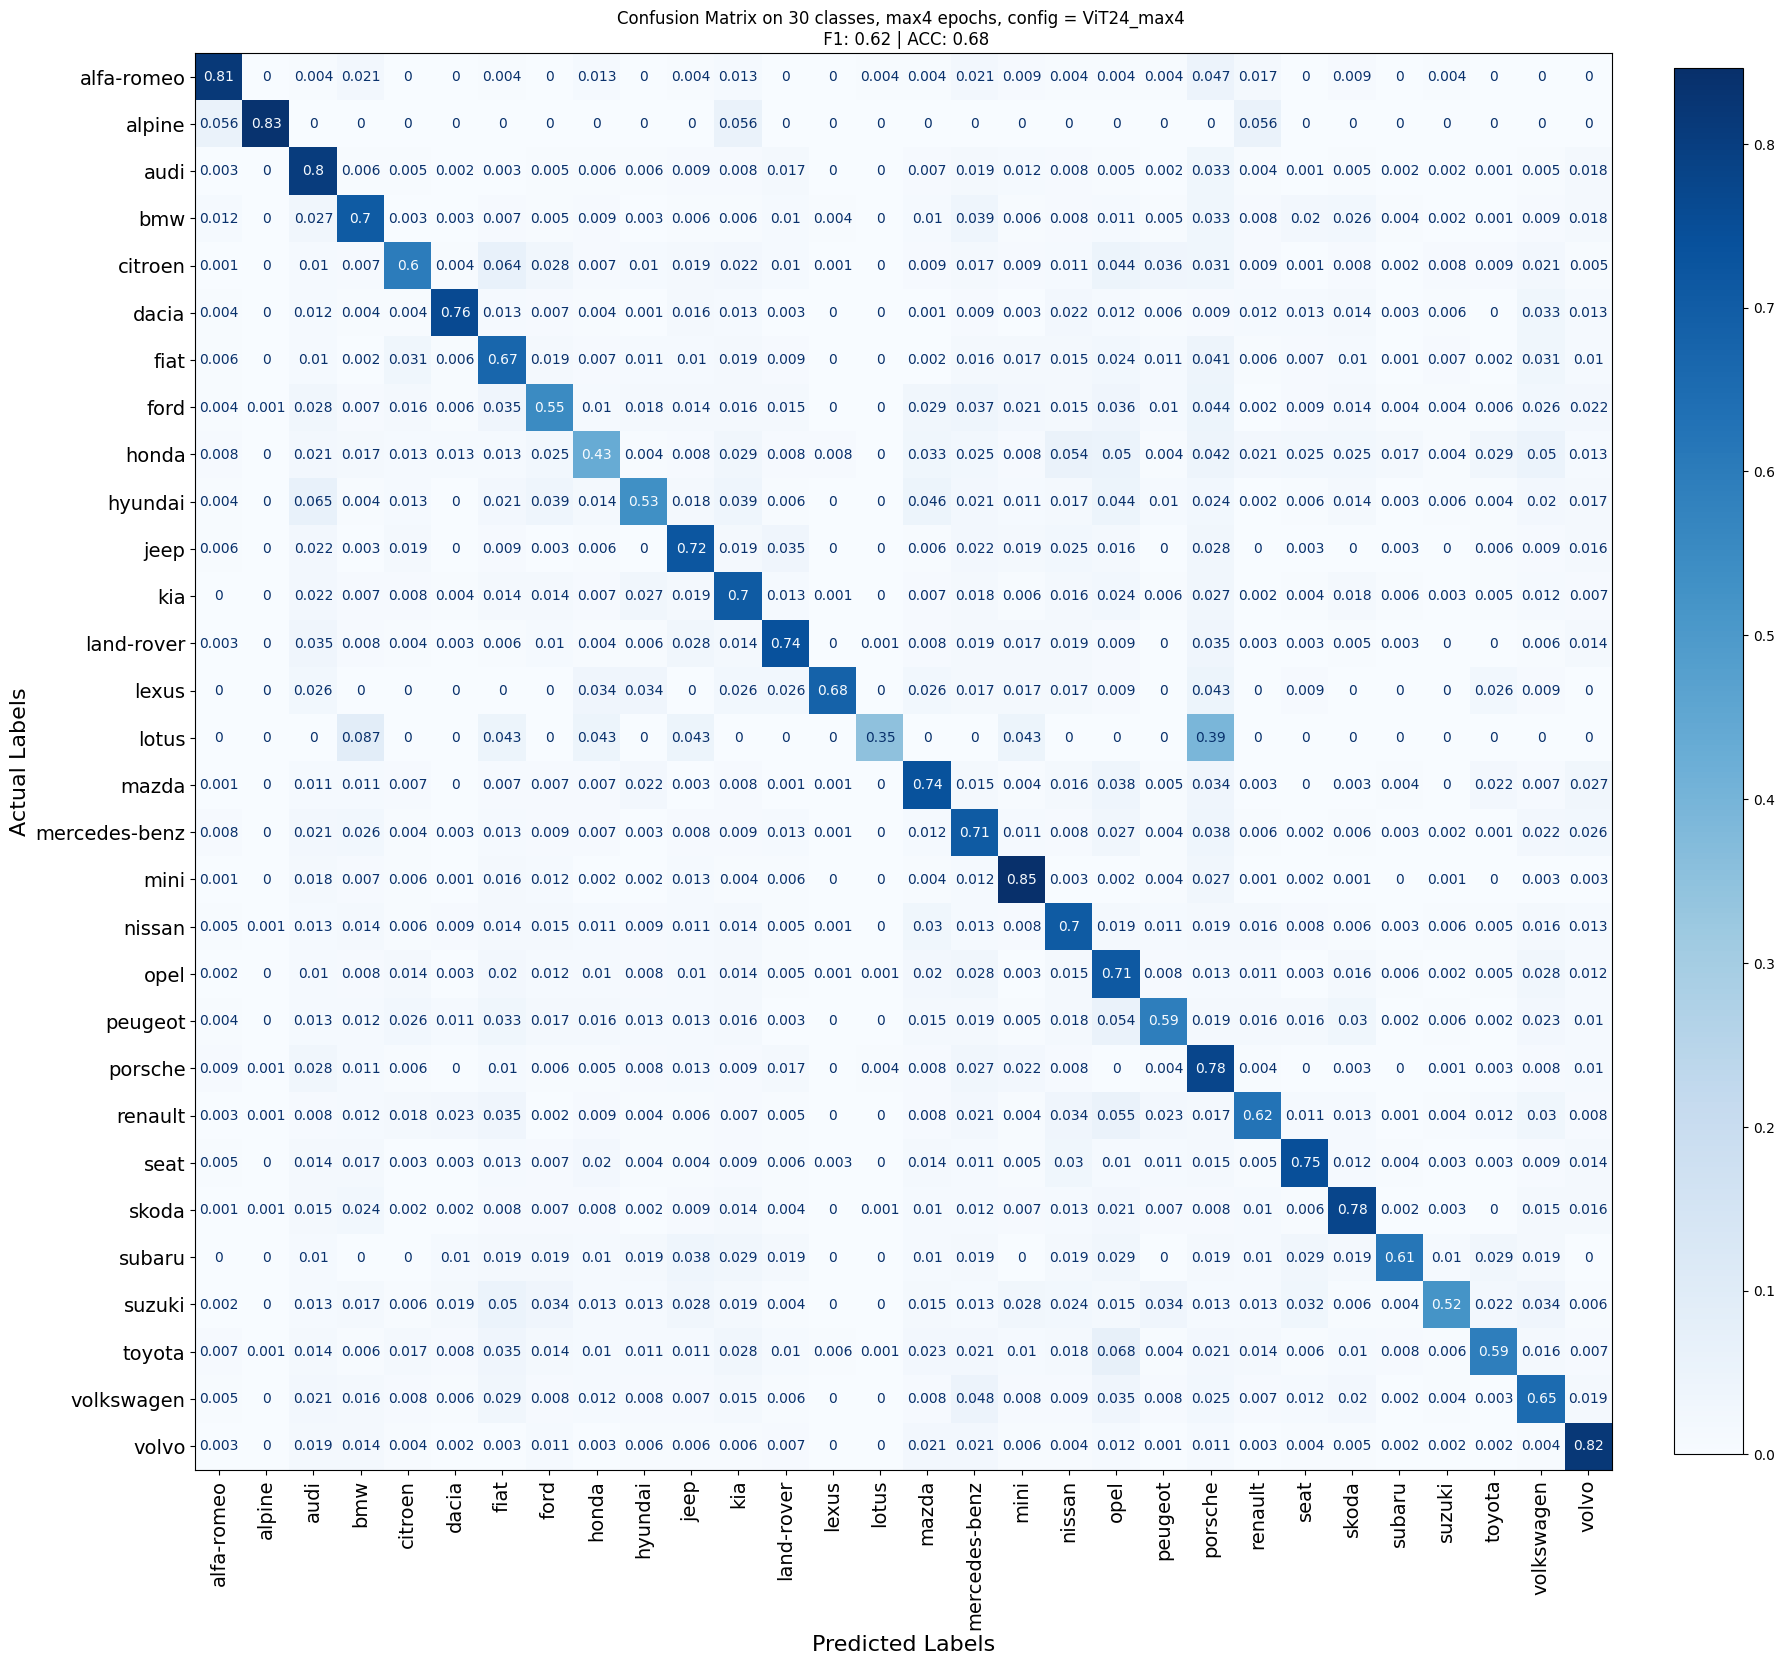

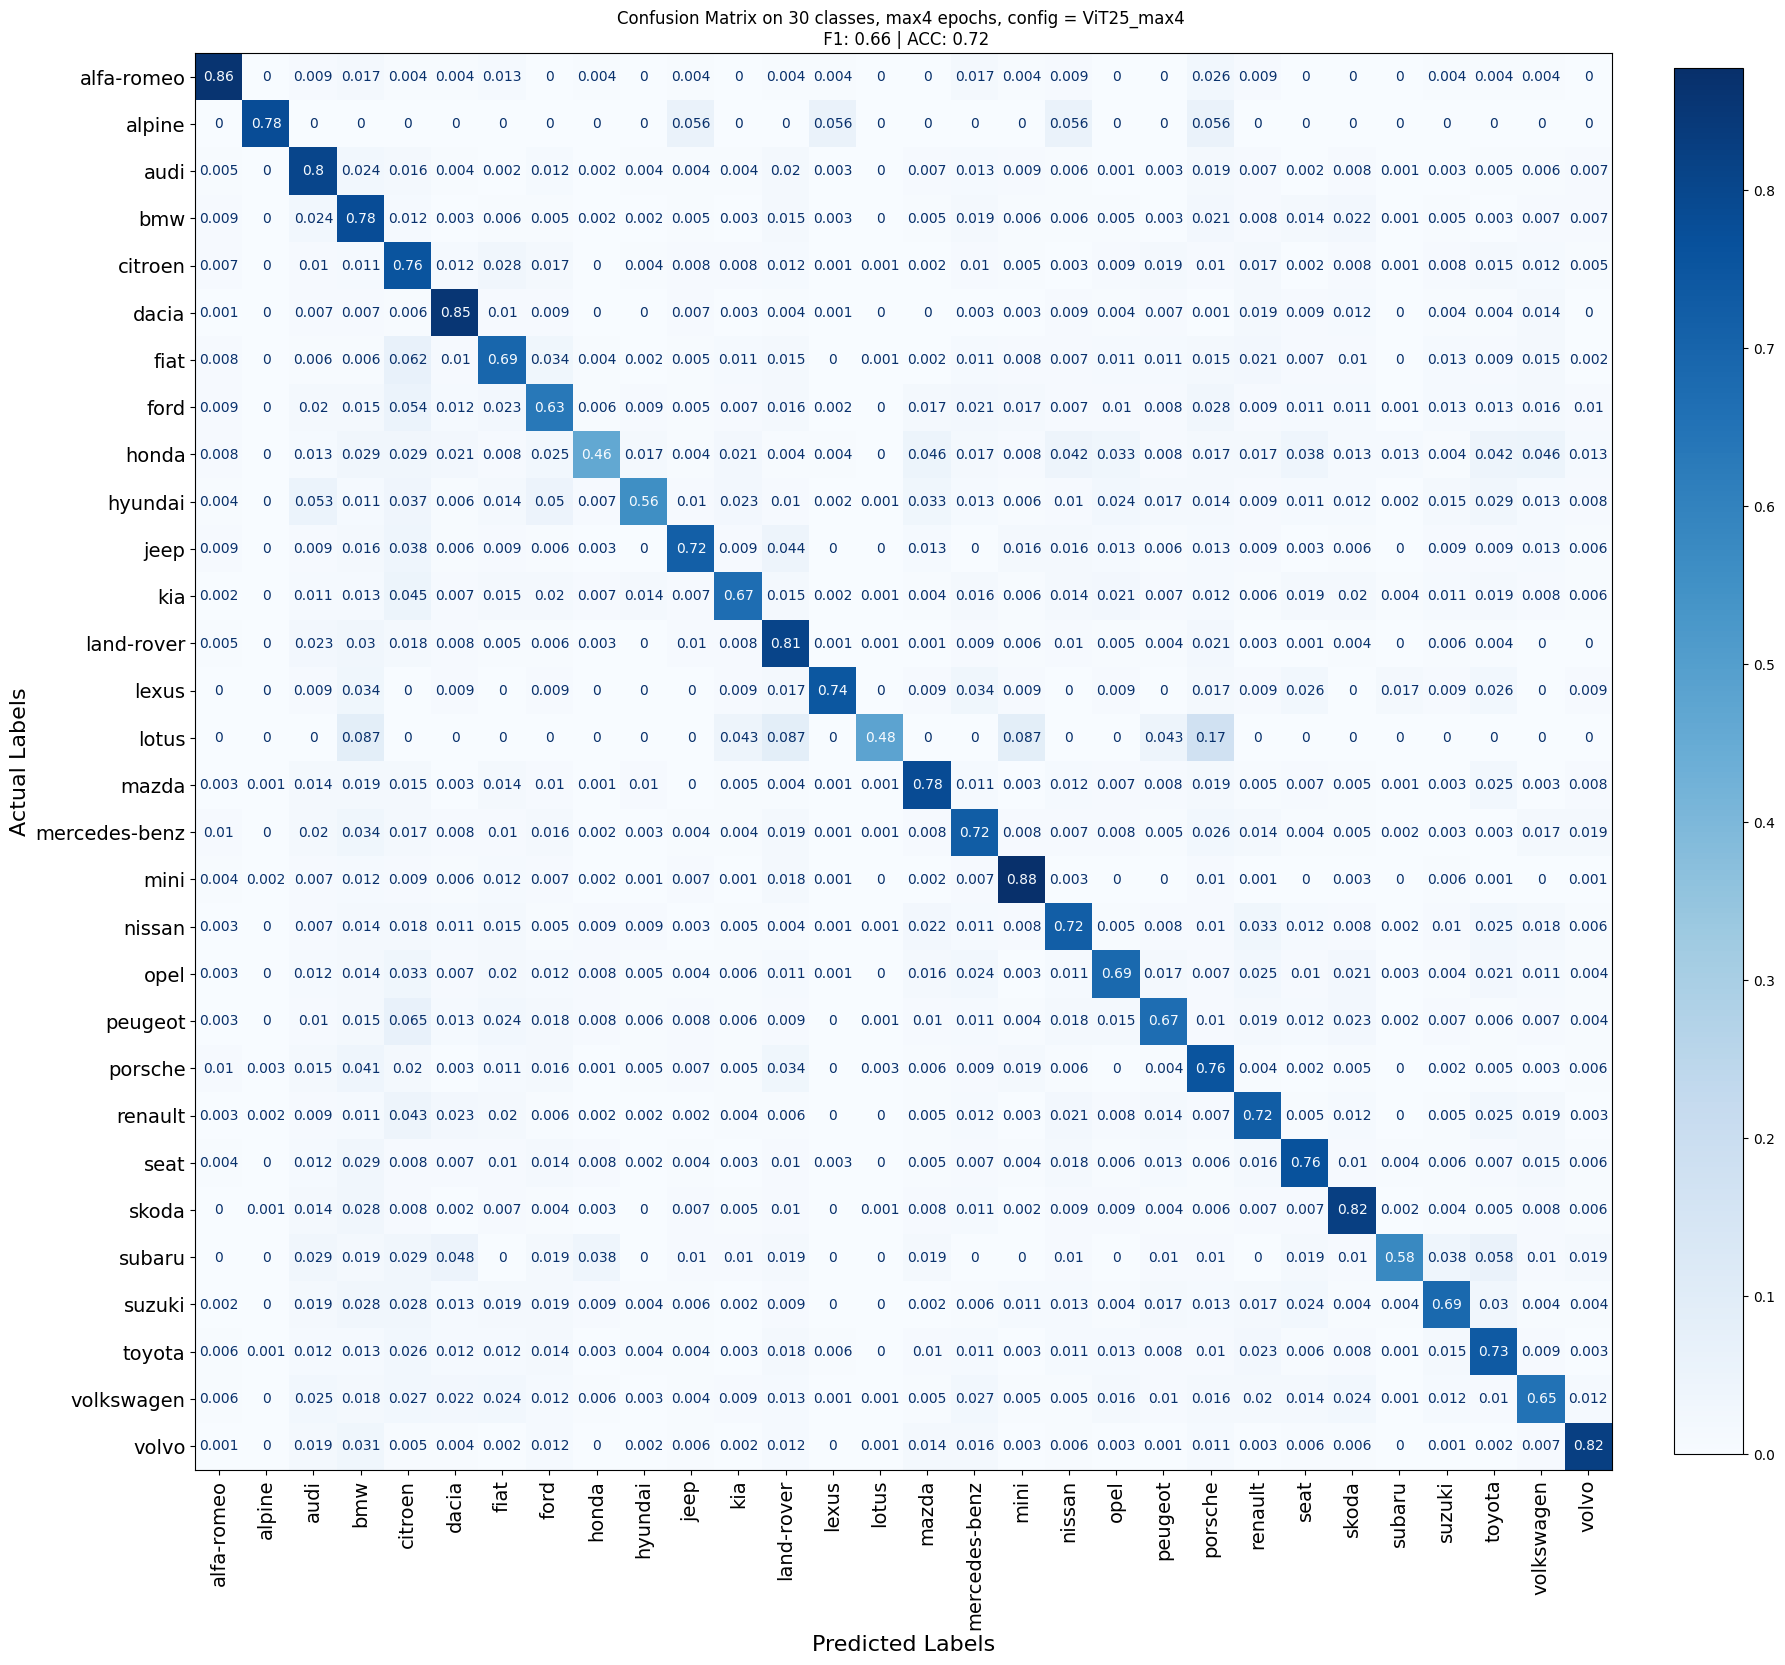

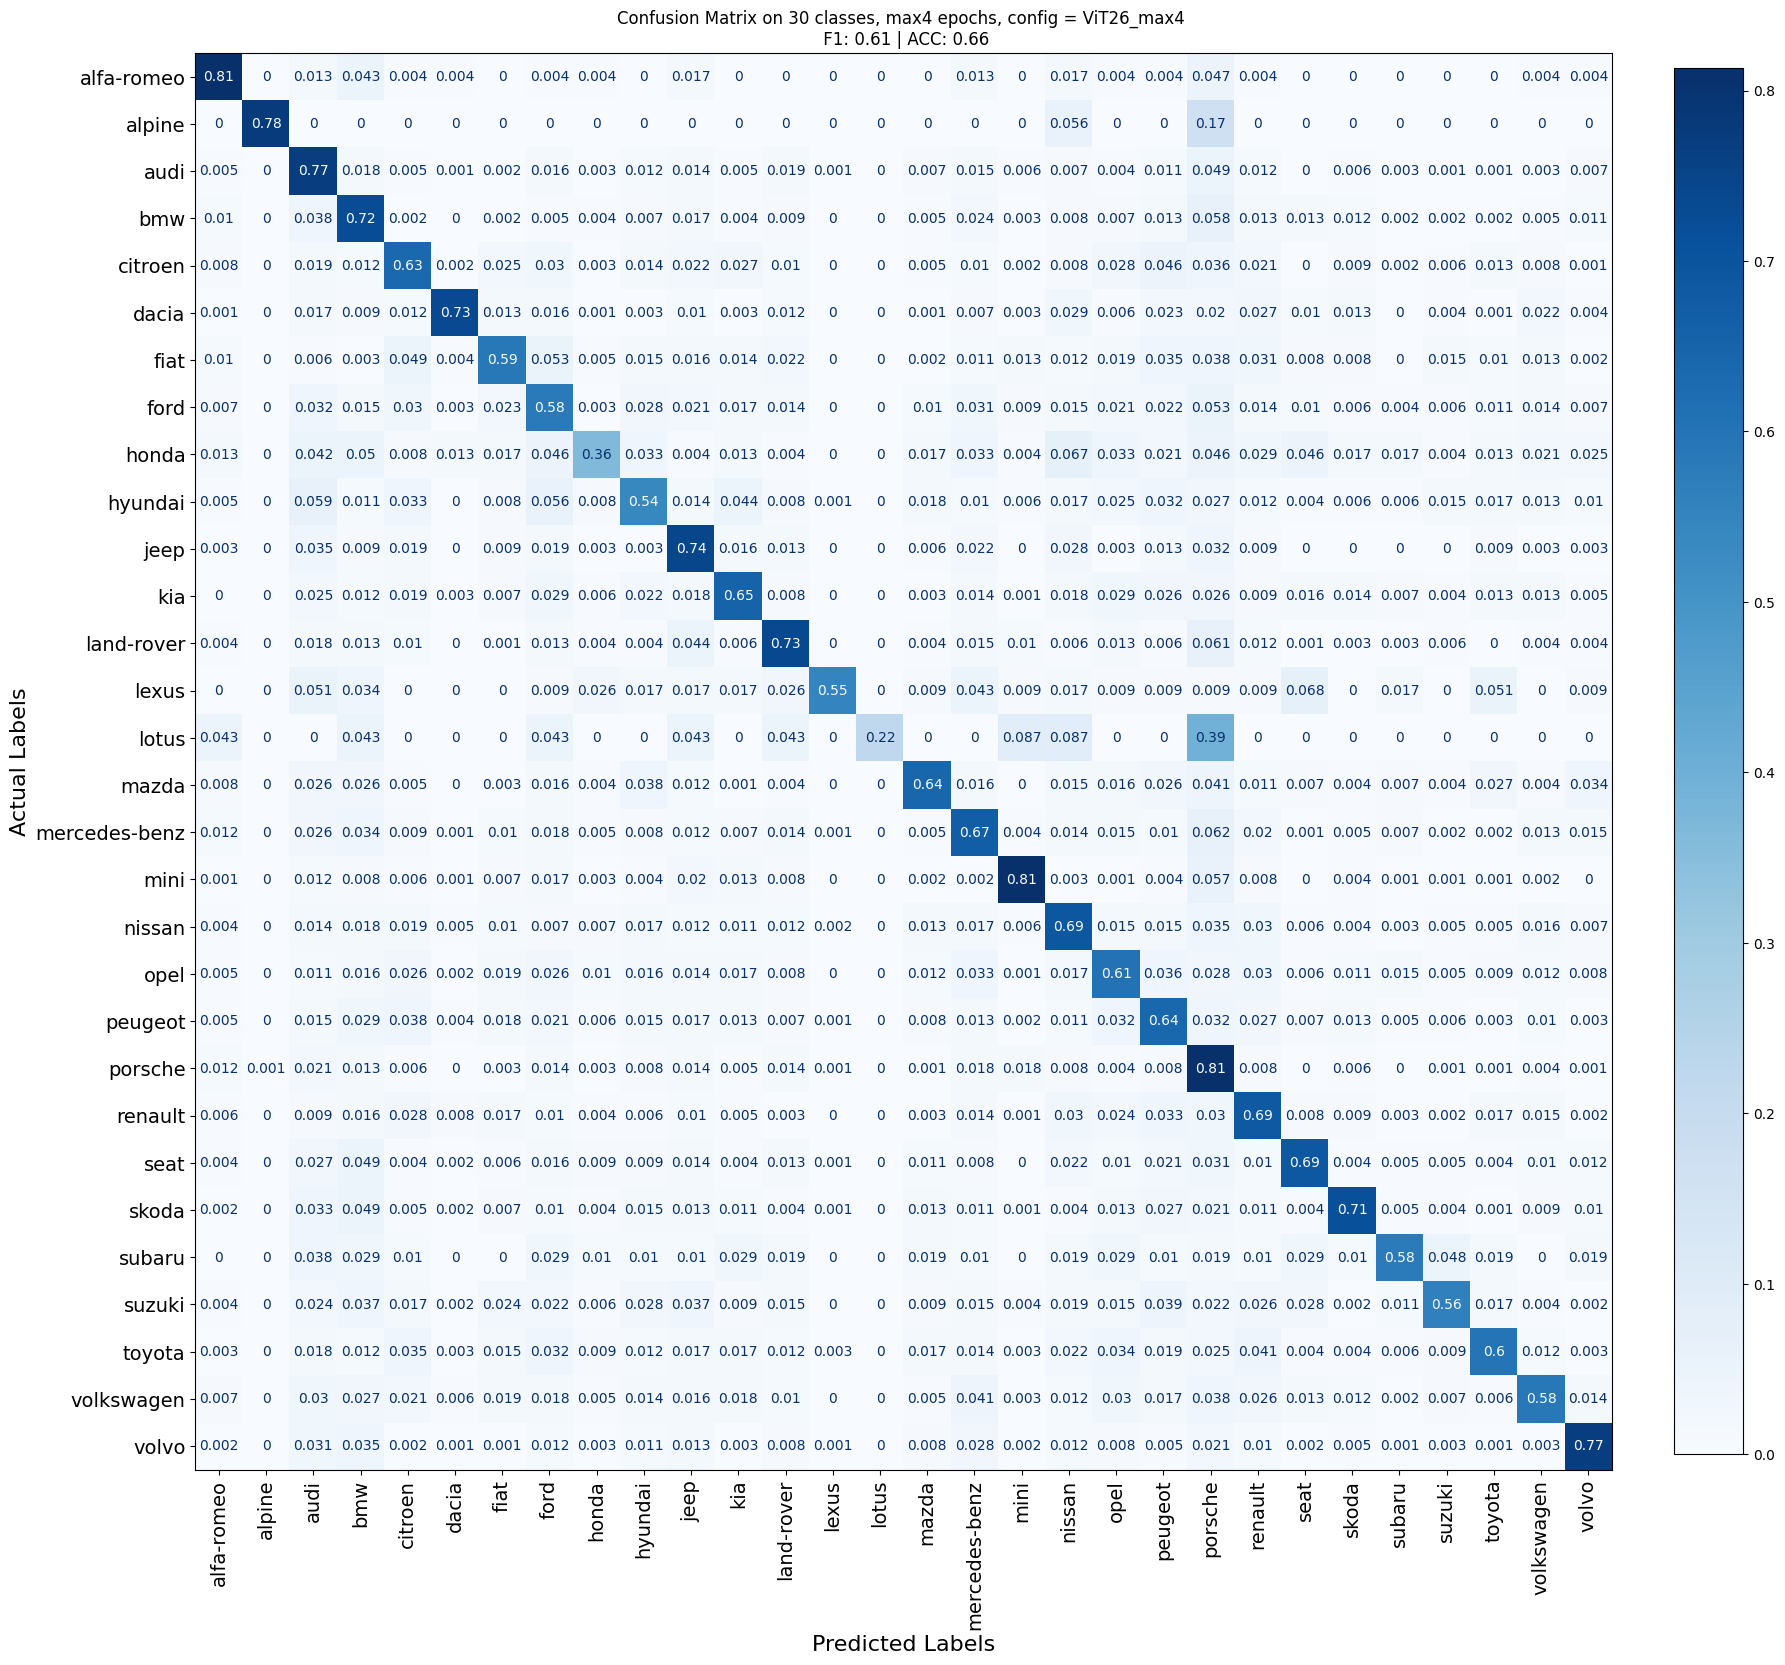

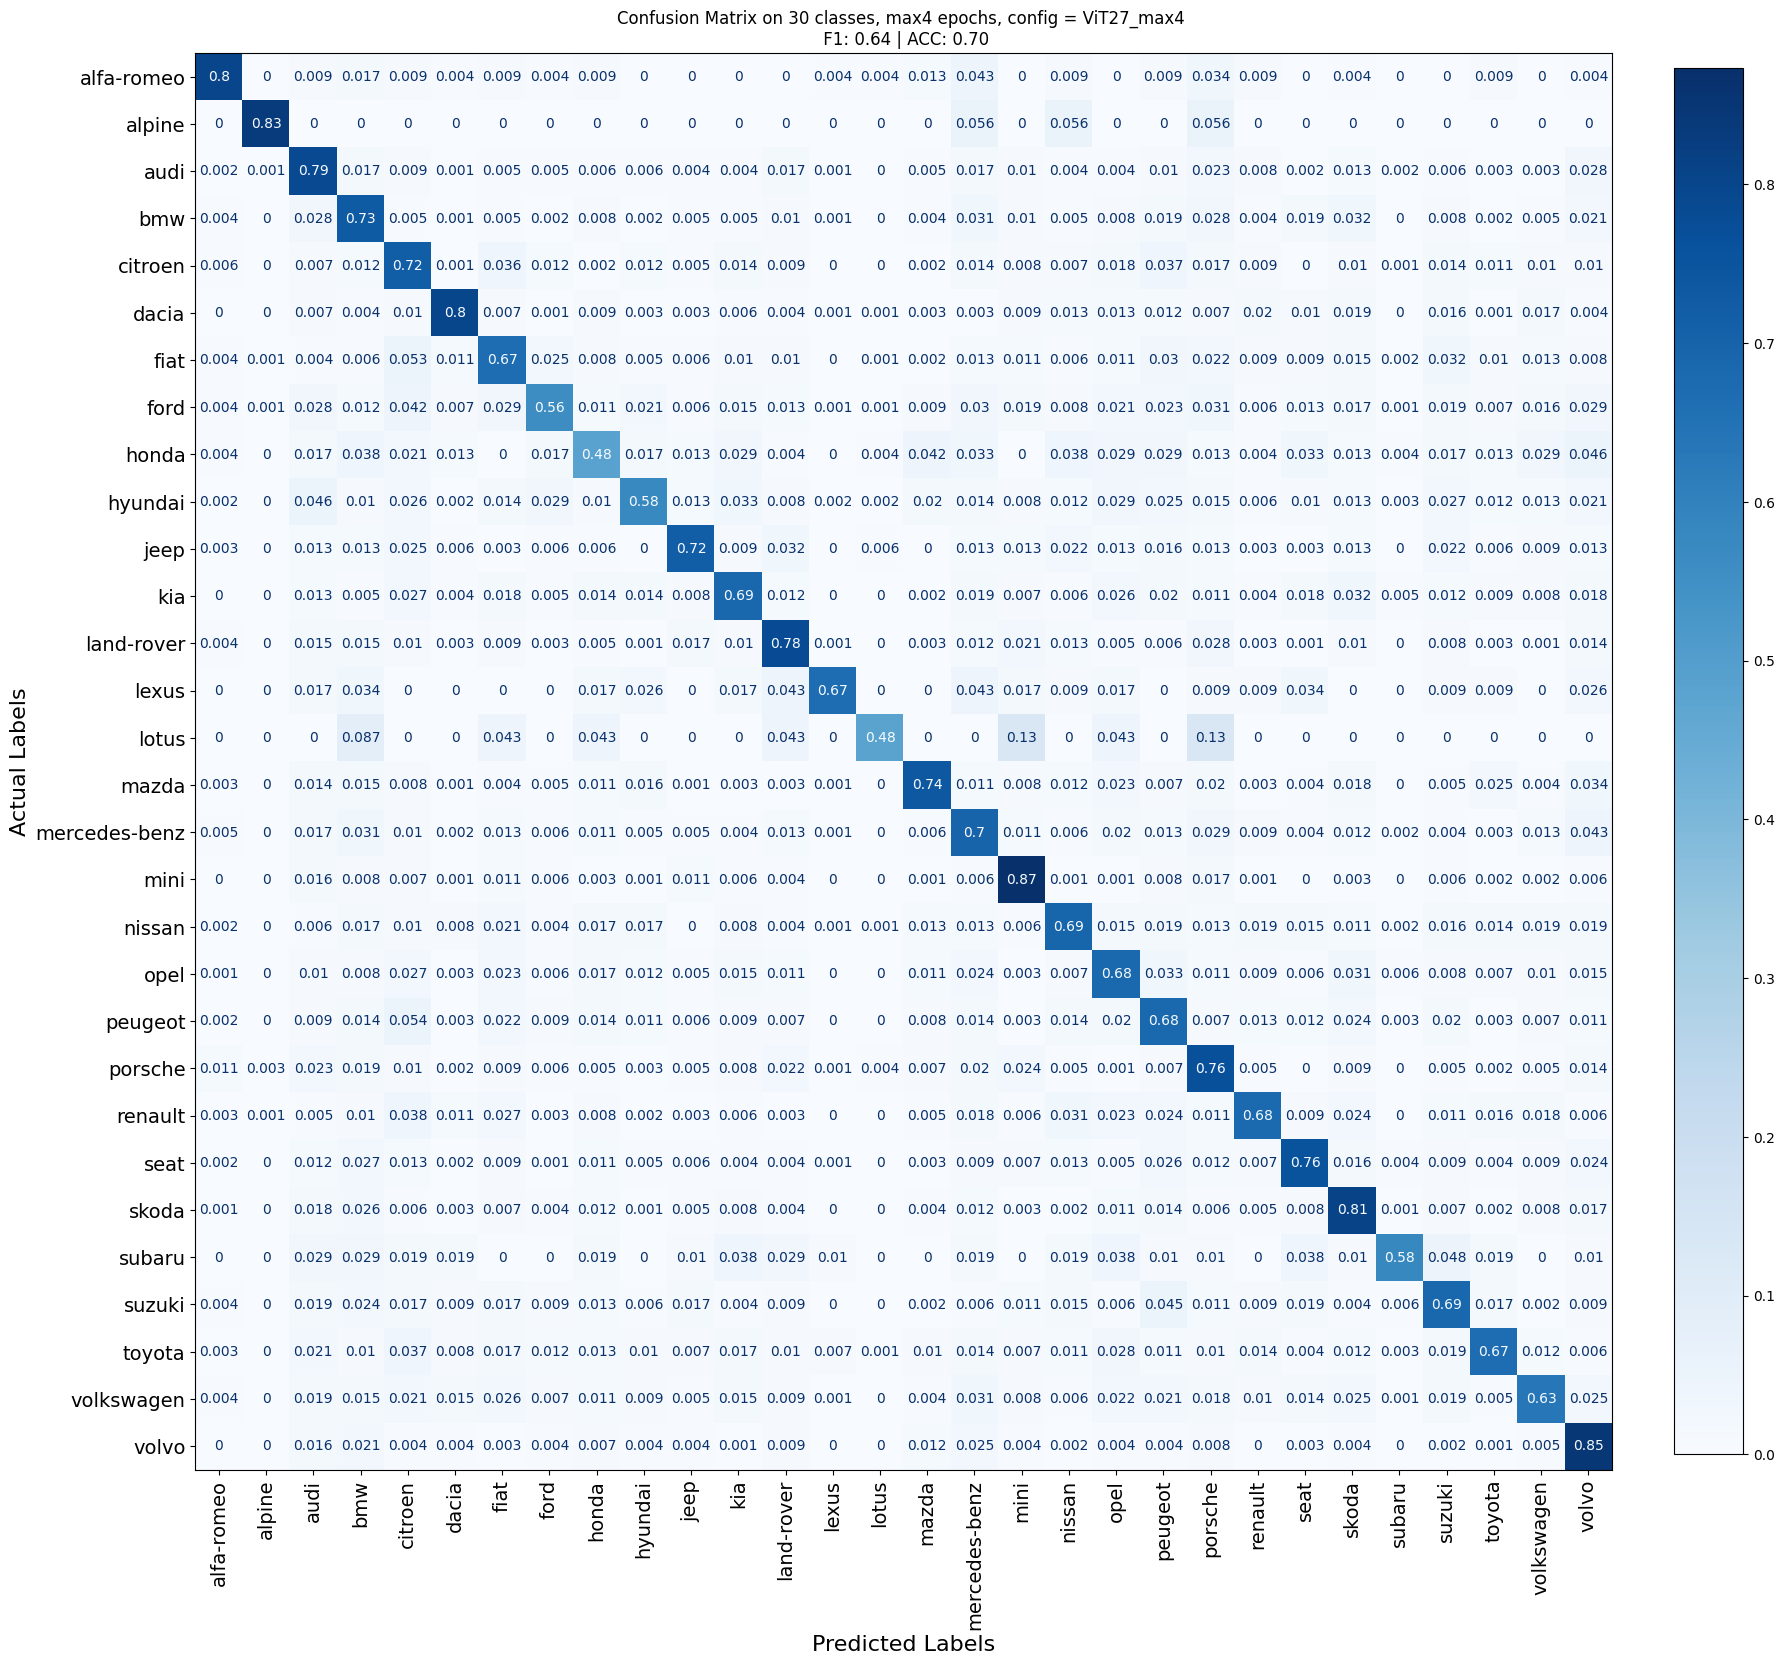

In [15]:
full_metrics = {}
for k in all_vit30_results:
    name = k
    pred = np.argmax(all_vit30_results[k], axis=1)
    act = all_vit30_actuals[k]['data']
    label_encoder = all_vit30_actuals[k]['encoder']
    metrics = implot.quick_metrics(act, pred)
    full_metrics[k] = metrics
    disp = implot.make_cm(act, pred, label_encoder.classes_)
    disp.title(f'Confusion Matrix on 30 classes, max4 epochs, config = {name} \n F1: {metrics["Macro F1 Score"]:.2f} | ACC: {metrics["Accuracy"]:.2f}')
    disp.show()

In [16]:
full_metrics

{'ViT17_max4': {'Accuracy': 0.6328760371313563,
  'Macro F1 Score': 0.5775362958401401,
  'Weighted F1 Score': 0.6585412889253998,
  "Cohen's Kappa": 0.6125599582091975,
  'Macro Precision': 0.5791751930106792,
  'Macro Recall': 0.6535257242145461,
  'Weighted Precision': 0.7308427367426092,
  'Weighted Recall': 0.6328760371313563},
 'ViT18_max4': {'Accuracy': 0.6191571510720447,
  'Macro F1 Score': 0.5724936783537673,
  'Weighted F1 Score': 0.6292908435119416,
  "Cohen's Kappa": 0.5970417609283805,
  'Macro Precision': 0.5590566856620018,
  'Macro Recall': 0.6293799767662788,
  'Weighted Precision': 0.683273623959684,
  'Weighted Recall': 0.6191571510720447},
 'ViT19_max4': {'Accuracy': 0.6735603384539555,
  'Macro F1 Score': 0.6198188124841895,
  'Weighted F1 Score': 0.6821465095254287,
  "Cohen's Kappa": 0.6533202280778404,
  'Macro Precision': 0.6125758906055345,
  'Macro Recall': 0.6704751990585446,
  'Weighted Precision': 0.7175583781946379,
  'Weighted Recall': 0.673560338453955

In [17]:
vit_compare = implot.plot_quick_metrics(full_metrics)
vit_compare.update_layout(
    width = 1920, 
    height= 1080, 
    title= '30 Class output ViT metrics comparison max4 epochs', 
    showlegend= False
)
#the dip for ViT21 is because the model has a larger BATCH size, but LR did not increase. 

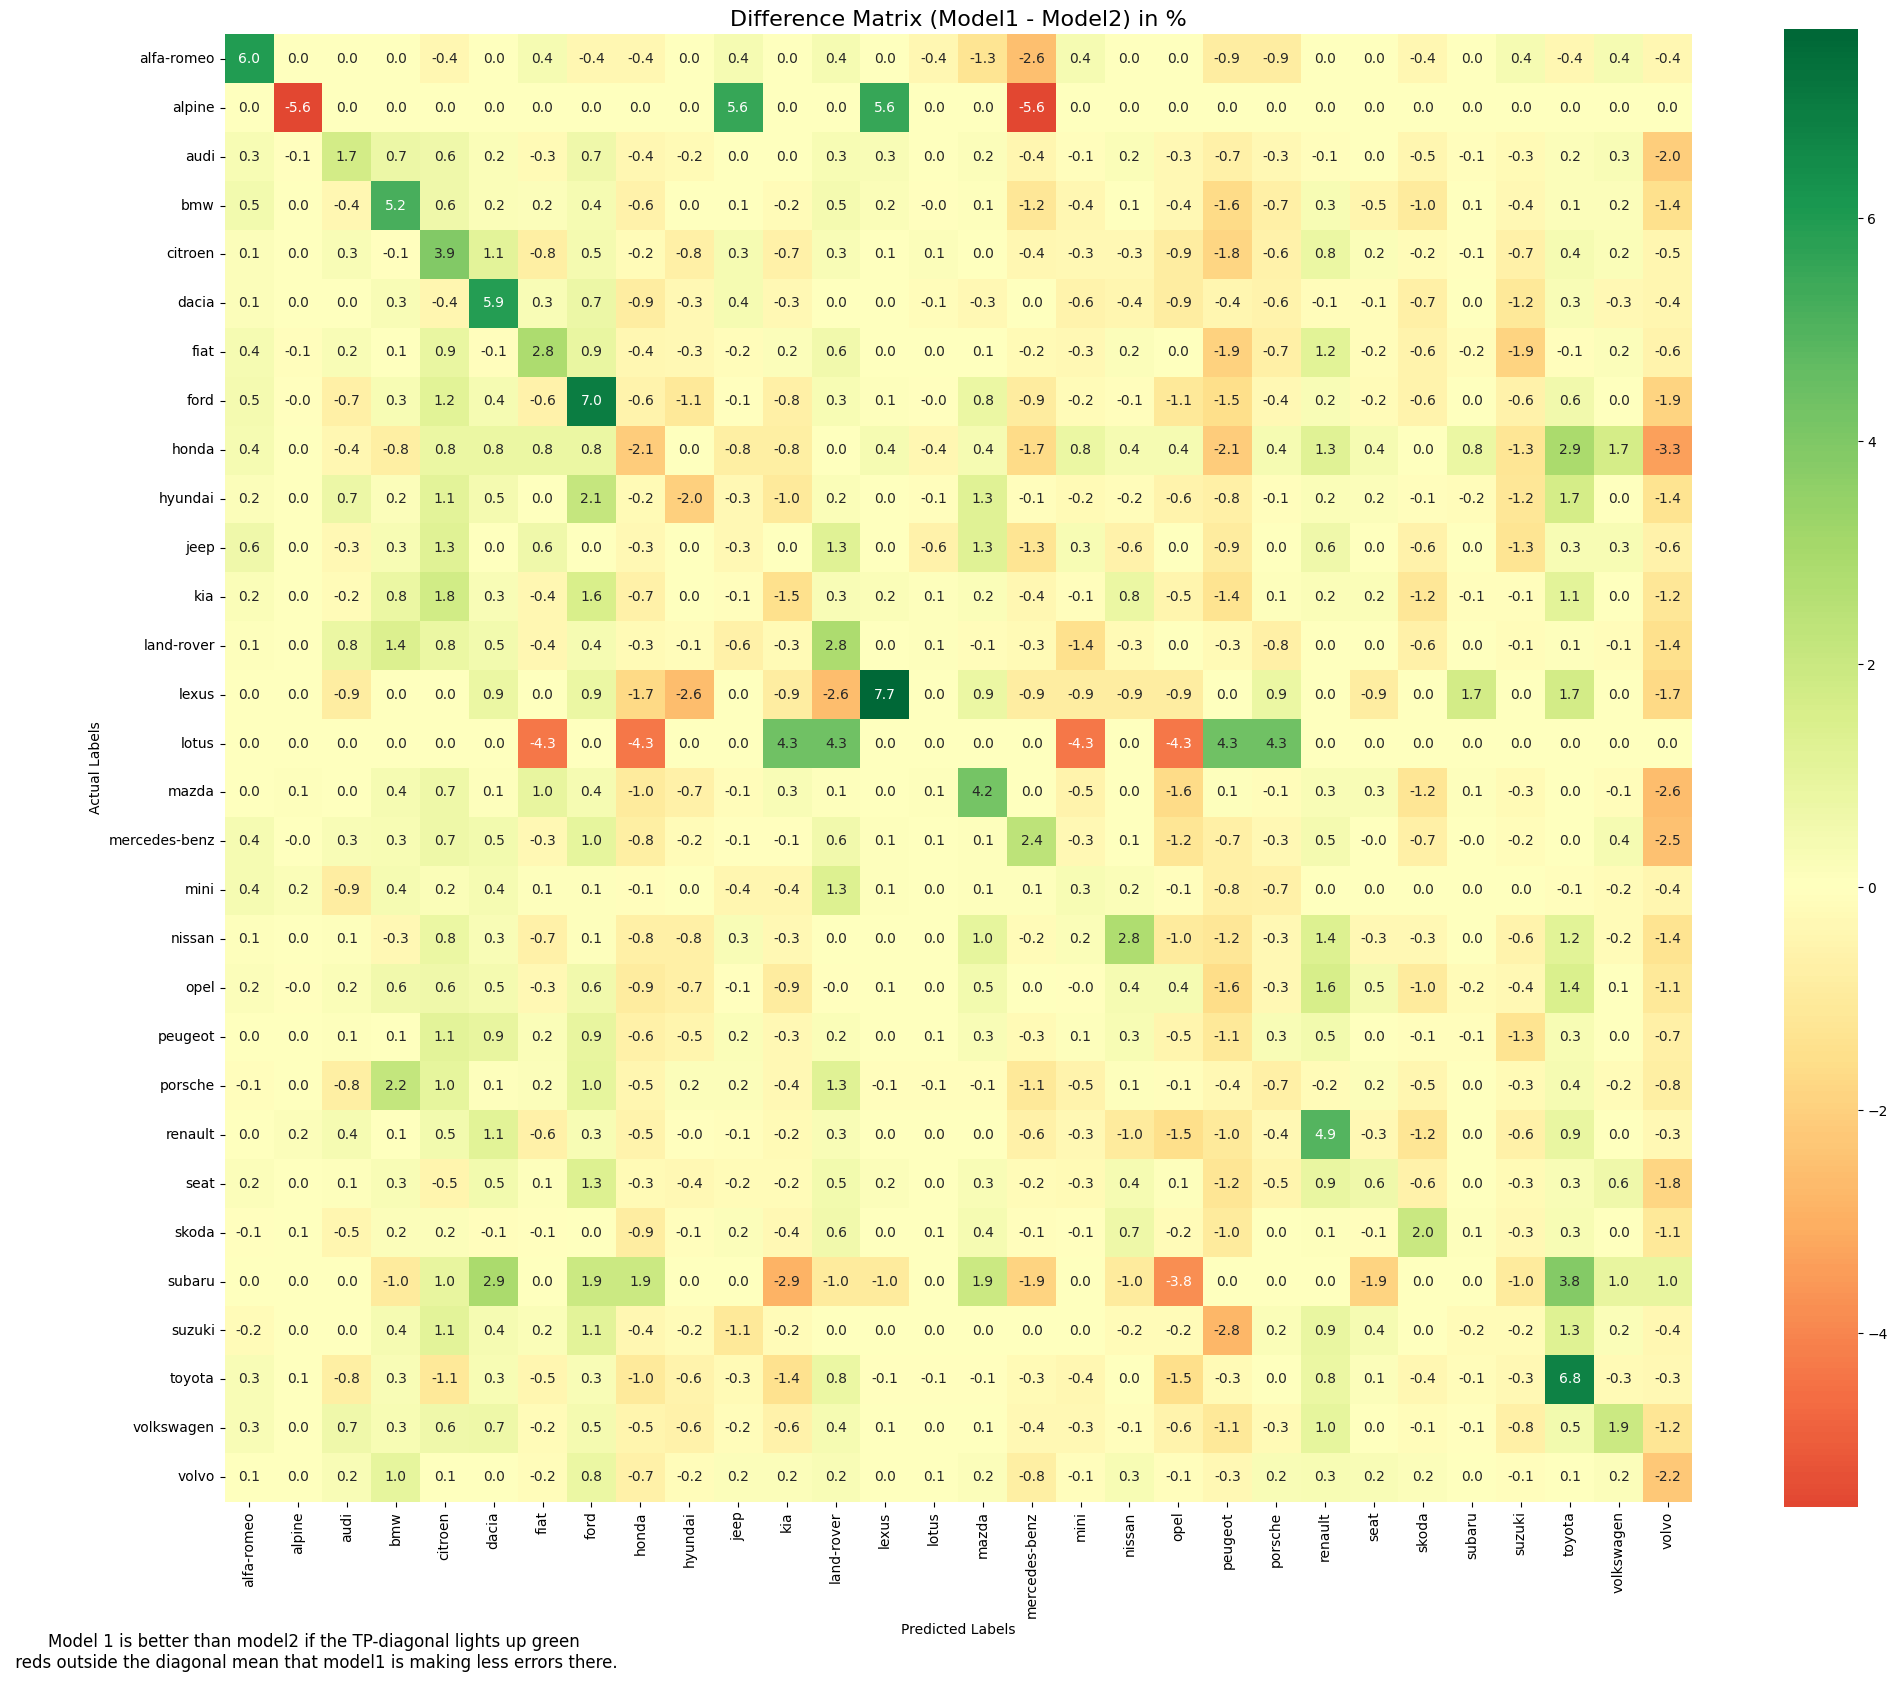

In [18]:
#25 and 27 look promissing: 
p1 = 'ViT25_max4'
p2 = 'ViT27_max4'

diff = implot.cm_delta(
        all_vit30_actuals[p1]['encoder'].inverse_transform(np.argmax(all_vit30_results[p1], axis=1)),
        all_vit30_actuals[p2]['encoder'].inverse_transform(np.argmax(all_vit30_results[p2], axis=1)),
        all_vit30_actuals[p1]['encoder'].inverse_transform(list(all_vit30_actuals[p1]['data'])), 
        label_encoder.classes_
    )

diff

### Conclusion
Based on the MAX_4 runconfigurations, it seems that the settings used in VIT25 are quite good - bear in mind that these were all stopped after four epochs, so in theory it is possible that the final convergence of another model will be higher.  The difference matrix lights up mostly green over the diagonal when you compare it to the second best performing ViTmodel (ViT27_max4) based on F1-score. Although we lose some 

We will copy the config of ViT25_max4 into ViT1_FULL and let it run for a max of 100 epochs on the full dataset. 